In [338]:
# Clustering Analysis

In [339]:
# Data preprocessing

In [340]:
# Load dataset

In [341]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

In [342]:
df=pd.read_excel('EastWestAirlines.xlsx',sheet_name='data')

In [343]:
df.head(3)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0


In [344]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [345]:
# No null values

In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [347]:
# All values are numerical

In [348]:
df['Award?'].value_counts()

Award?
0    2518
1    1481
Name: count, dtype: int64

# Data Preprocessing:


## 1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.

In [ ]:
# Detecting outliers

In [350]:
# # Initialize a dictionary to store outliers for each column
# outliers_dict = {}

# # Loop through each column in the DataFrame
# for column in df.columns:
#     # Calculate IQR for the current column
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1

#     # Identify outliers for the current column
#     outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
#     outliers_dict[column] = outliers

#     # Print outliers for the current column
#     print(f"Outliers based on IQR for column {column}:\n", outliers)
#     print(f"Number of outliers in column {column}: {len(outliers)}\n")

# # Optional: Combine all outliers into a single DataFrame (if needed)
# all_outliers = pd.concat(outliers_dict.values()).drop_duplicates()
# print("Total unique outliers across all columns:\n", all_outliers)
# print(f"Total number of unique outliers: {len(all_outliers)}")


In [351]:
# Finding value counts of each coulmn in a dataframe

In [352]:
for col in df.columns:
    print (f'Value counts for columns [{col}] in df: {df[col].value_counts()}\n')

Value counts for columns [ID#] in df: ID#
1       1
2691    1
2678    1
2679    1
2680    1
       ..
1351    1
1352    1
1353    1
1354    1
4021    1
Name: count, Length: 3999, dtype: int64

Value counts for columns [Balance] in df: Balance
1000     10
500       5
2000      5
1500      4
5000      3
         ..
9554      1
30130     1
12665     1
9860      1
3016      1
Name: count, Length: 3904, dtype: int64

Value counts for columns [Qual_miles] in df: Qual_miles
0       3773
1000      17
500       15
967        4
888        4
        ... 
4116       1
1388       1
1896       1
3692       1
1005       1
Name: count, Length: 164, dtype: int64

Value counts for columns [cc1_miles] in df: cc1_miles
1    2289
3     613
4     525
5     288
2     284
Name: count, dtype: int64

Value counts for columns [cc2_miles] in df: cc2_miles
1    3956
2      28
3      15
Name: count, dtype: int64

Value counts for columns [cc3_miles] in df: cc3_miles
1    3981
4       6
5       5
3       4
2       3

In [353]:
for col in df.columns:
    print (f'Unique counts for columns [{col}] in df: {df[col].nunique()}\n')

Unique counts for columns [ID#] in df: 3999

Unique counts for columns [Balance] in df: 3904

Unique counts for columns [Qual_miles] in df: 164

Unique counts for columns [cc1_miles] in df: 5

Unique counts for columns [cc2_miles] in df: 3

Unique counts for columns [cc3_miles] in df: 5

Unique counts for columns [Bonus_miles] in df: 2734

Unique counts for columns [Bonus_trans] in df: 57

Unique counts for columns [Flight_miles_12mo] in df: 343

Unique counts for columns [Flight_trans_12] in df: 35

Unique counts for columns [Days_since_enroll] in df: 2820

Unique counts for columns [Award?] in df: 2



In [354]:
# The columns IDs can be set as index column

In [355]:
df1=df.set_index('ID#')

In [356]:
df1

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
1,28143,0,1,1,1,174,1,0,0,7000,0
2,19244,0,1,1,1,215,2,0,0,6968,0
3,41354,0,1,1,1,4123,4,0,0,7034,0
4,14776,0,1,1,1,500,1,0,0,6952,0
5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
4017,18476,0,1,1,1,8525,4,200,1,1403,1
4018,64385,0,1,1,1,981,5,0,0,1395,1
4019,73597,0,3,1,1,25447,8,0,0,1402,1


In [357]:
# Outlier visualization through histograms and boxplots

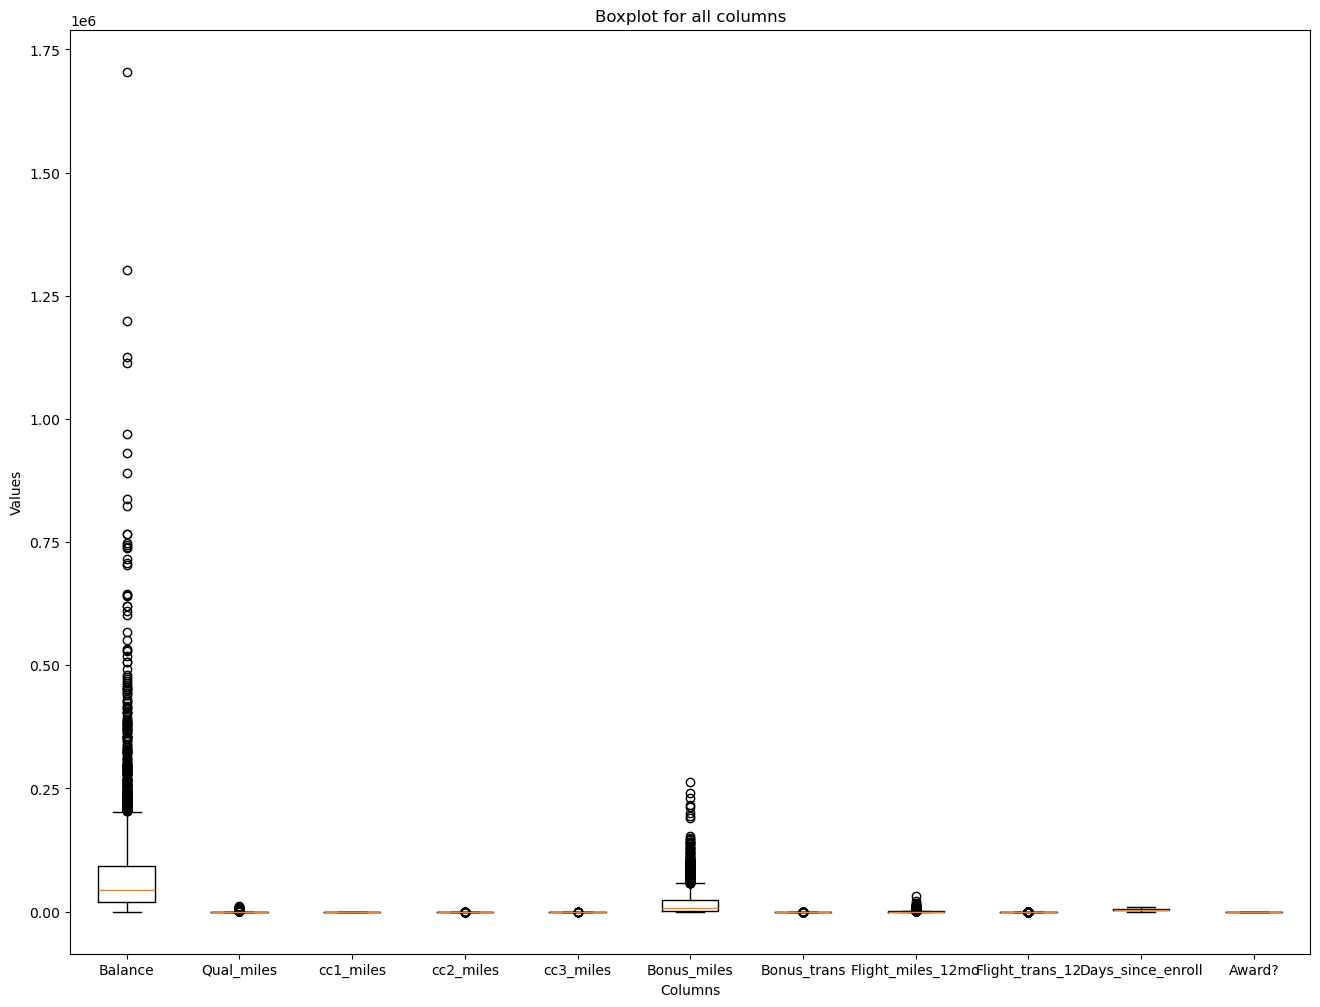

In [358]:
plt.figure(figsize=(16,12)) 
plt.boxplot([df1[col] for col in df1.columns], tick_labels=df1.columns)
plt.title("Boxplot for all columns")
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

# Visualizing boxplot with matplotlib

In [359]:
# Histograms

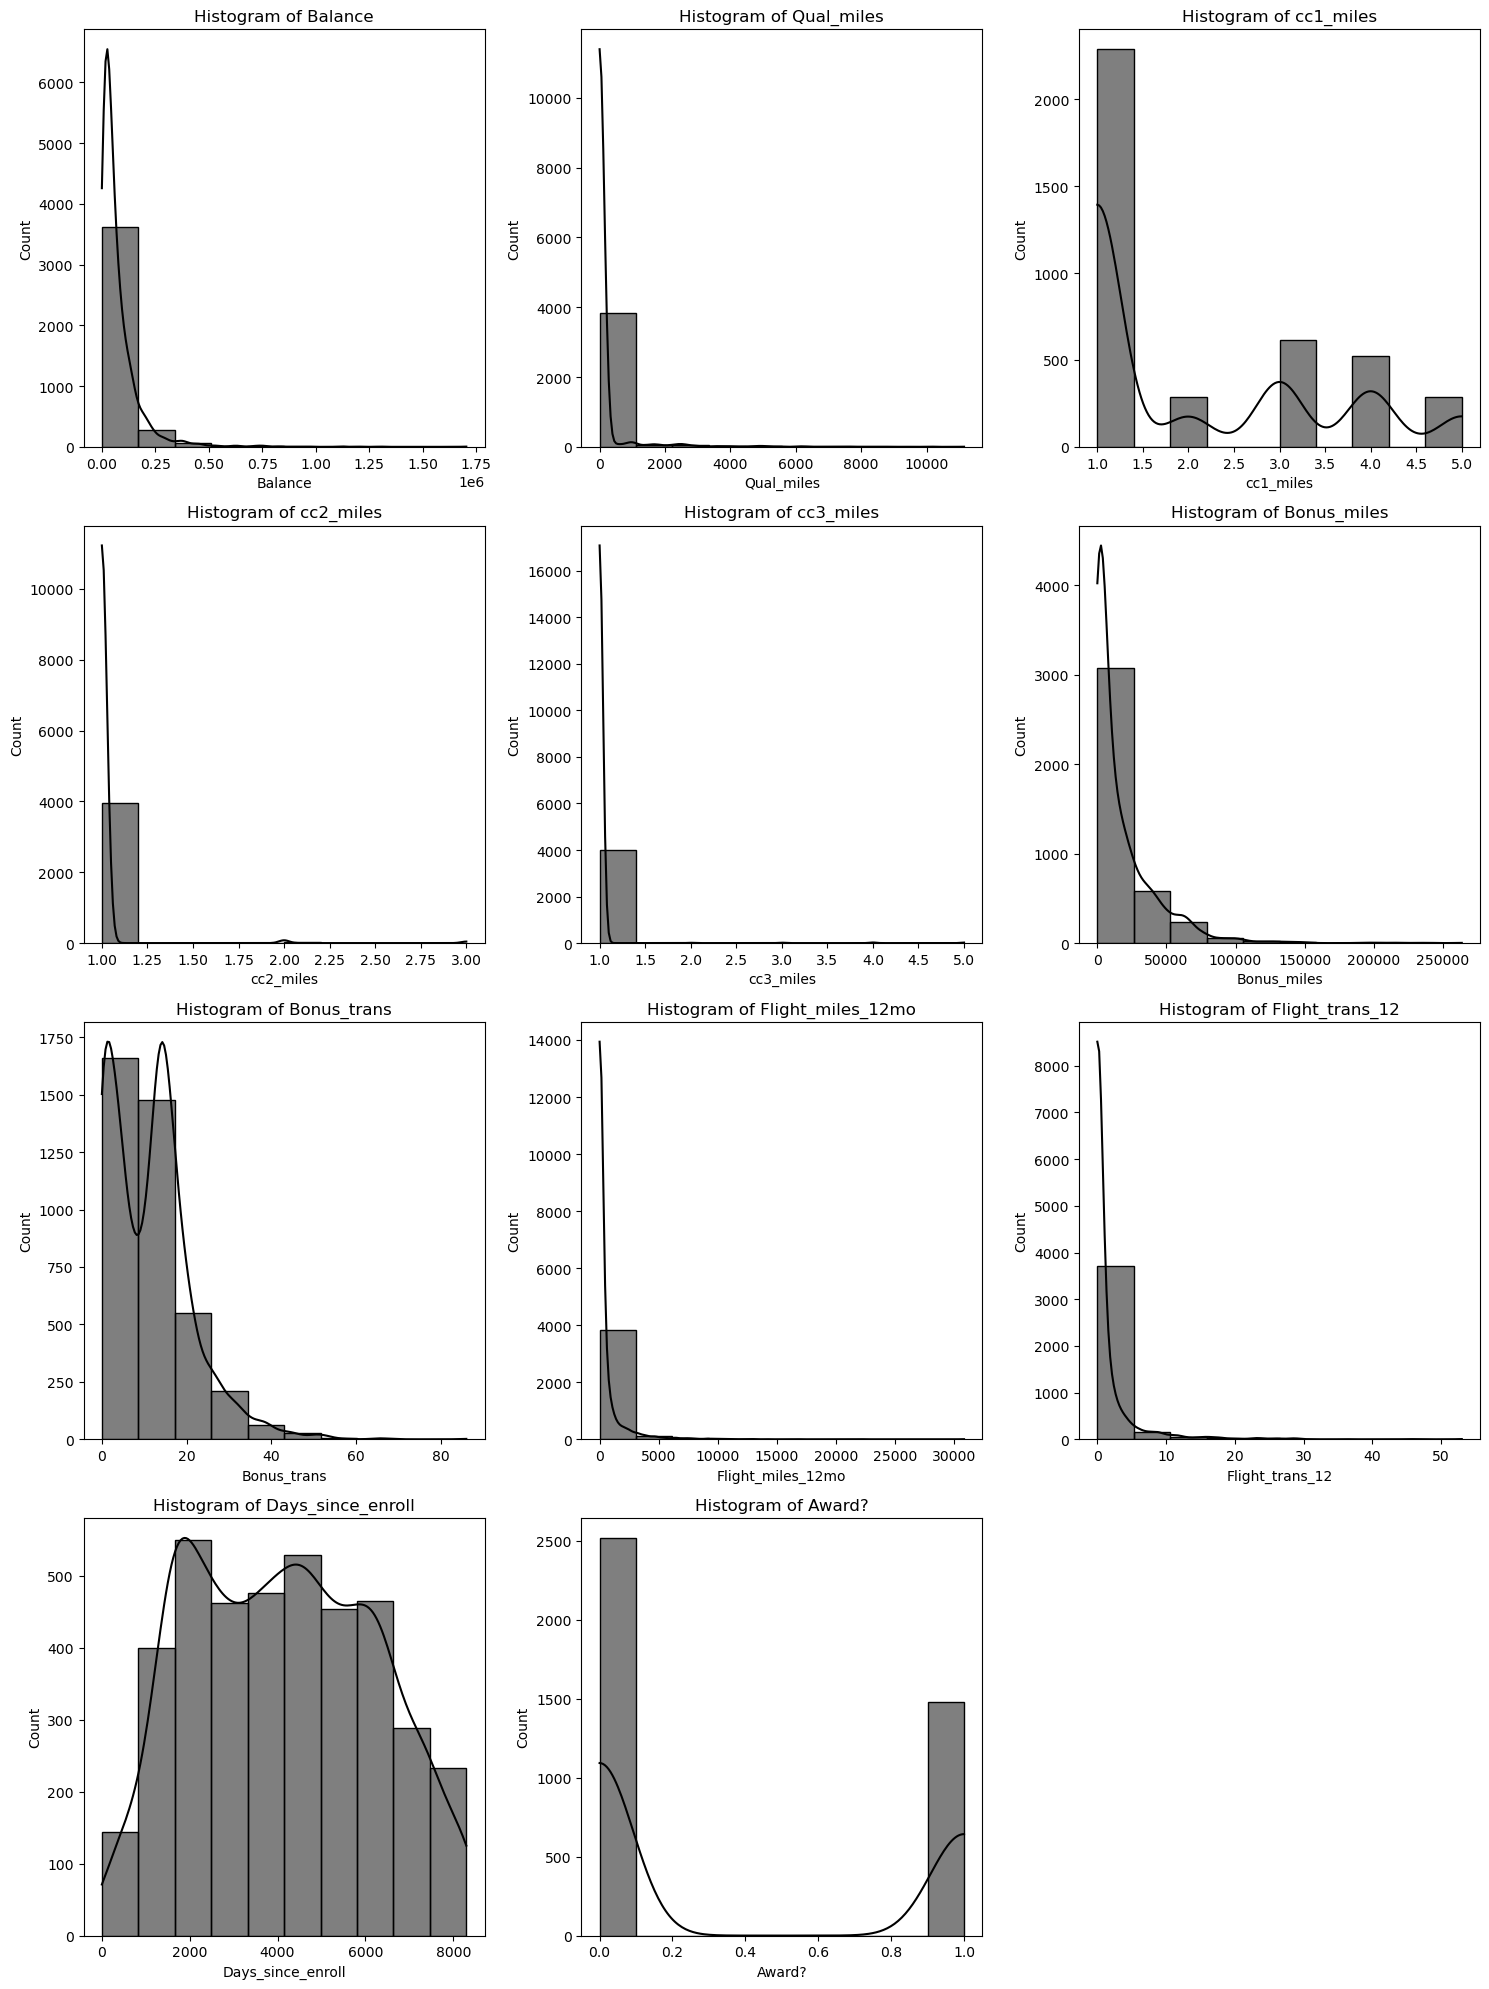

In [360]:
import math
import seaborn as sns
num_cols = len(df1.columns)
rows=math.ceil(num_cols/3)

plt.figure(figsize=(15, rows*5))
for i, col in enumerate(df1.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df1[col],kde=True,bins=10,color='black')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [361]:
# Initialize a dictionary to store outliers for each column
outliers_dict = {}

# Loop through each column in the DataFrame
for column in df1.columns:
    # Calculate IQR for the current column
    Q1 = df1[column].quantile(0.25)
    Q3 = df1[column].quantile(0.75)
    IQR = Q3 - Q1

    # Identify outliers for the current column
    outliers = df1[(df1[column] < (Q1 - 1.5 * IQR)) | (df1[column] > (Q3 + 1.5 * IQR))]
    outliers_dict[column] = outliers

    # Print outliers for the current column
    print(f"Outliers based on IQR for column [{column}]:\n", outliers)
    print(f"Number of outliers in column [{column}]: {len(outliers)}\n")



Outliers based on IQR for column [Balance]:
       Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
ID#                                                                       
9      443003           0          3          2          1         1753   
25     205651         500          1          1          1         4025   
33     276571           0          4          1          1        42044   
44     619393           0          3          1          1        15008   
46     288865         967          1          1          1        23600   
...       ...         ...        ...        ...        ...          ...   
3777   221543           0          1          1          1        10300   
3779   203353           0          1          1          1        14000   
3795   822321           0          5          1          1       138334   
3811   374613           0          1          2          1        23592   
3862   204693           0          1          1        

In [362]:
# Optional: Combine all outliers into a single DataFrame (if needed)
all_outliers = pd.concat(outliers_dict.values()).drop_duplicates()
print("Total unique outliers across all columns:\n", all_outliers)
print(f"Total number of unique outliers: {len(all_outliers)}")


Total unique outliers across all columns:
       Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
ID#                                                                       
9      443003           0          3          2          1         1753   
25     205651         500          1          1          1         4025   
33     276571           0          4          1          1        42044   
44     619393           0          3          1          1        15008   
46     288865         967          1          1          1        23600   
...       ...         ...        ...        ...        ...          ...   
3778    77978           0          1          1          1         1373   
3813    73159           0          1          1          1          358   
3886    16152           0          1          1          1         6129   
3921    44324           0          1          1          1          650   
3953    40424           0          4          1          

In [363]:
df1.shape

(3999, 11)

In [364]:
(1124/3999)*100

28.107026756689173

In [365]:
# Outlier treatment in column 'Balance'

In [580]:
df_n=df1

In [634]:
Q1 = df1['Balance'].quantile(0.25)
Q3 = df1['Balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
# df_n['Balance'] =np.where((df1['Balance'] >= lower_bound) & (df1['Balance'] <= upper_bound), df1['Balance'], np.nan)



In [618]:
import numpy as np

# Calculate lower and upper bounds for outliers in the 'Balance' column
Q1 = df1['Balance'].quantile(0.25)
Q3 = df1['Balance'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Replace outliers with NaN or any other value (e.g., keep the original if within bounds)
df_w = df1.copy()
df_w['Balance'] = np.where(
    (df1['Balance'] >= lower_bound) & (df1['Balance'] <= upper_bound),
    df1['Balance'],  # Keep the original value if within bounds
    np.nan           # Replace outliers with NaN (you can change it to 0 or some other value)
)


In [622]:
df_w.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3733.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,53831.927940,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,46937.887757,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,17481.000000,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,38671.000000,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,77540.000000,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,202636.000000,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [624]:
df_w.isnull().sum()

Balance              266
Qual_miles             0
cc1_miles              0
cc2_miles              0
cc3_miles              0
Bonus_miles            0
Bonus_trans            0
Flight_miles_12mo      0
Flight_trans_12        0
Days_since_enroll      0
Award?                 0
dtype: int64

In [584]:
df_n.head(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
1,28143,0,1,1,1,174,1,0,0,7000,0
2,19244,0,1,1,1,215,2,0,0,6968,0


In [586]:
df1['Balance'].describe()

count    3.999000e+03
mean     7.360133e+04
std      1.007757e+05
min      0.000000e+00
25%      1.852750e+04
50%      4.309700e+04
75%      9.240400e+04
max      1.704838e+06
Name: Balance, dtype: float64

In [588]:
df_n['Balance'].describe()

count      3733.000000
mean      53831.927940
std       46937.887757
min           0.000000
25%       17481.000000
50%       38671.000000
75%       77540.000000
max      202636.000000
Name: Balance, dtype: float64

In [590]:
df1['Balance'].value_counts()

Balance
1000     10
500       5
2000      5
1500      4
5000      3
         ..
9554      1
30130     1
12665     1
9860      1
3016      1
Name: count, Length: 3904, dtype: int64

In [592]:
df_n['Balance'].value_counts()

Balance
1000     10
500       5
2000      5
1500      4
41279     3
         ..
77709     1
22533     1
25302     1
11908     1
3016      1
Name: count, Length: 3638, dtype: int64

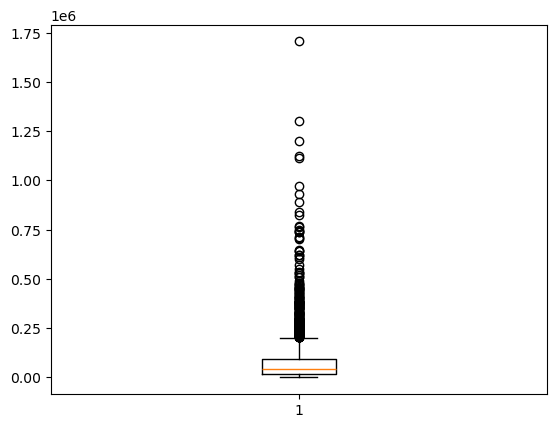

In [594]:
# data_box=data_cleaned3.dropna()
data_box=df1.Balance
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

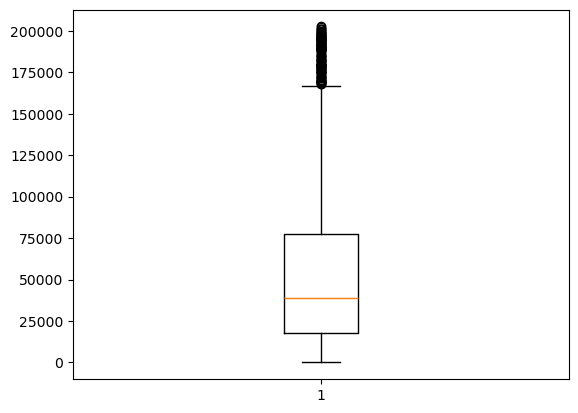

In [596]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Balance
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [526]:
df1.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [528]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000,3733.000000
mean,53831.927940,131.015001,1.986874,1.014733,1.012323,15328.525047,11.081704,401.579427,1.189928,4016.226895,0.353871
std,46937.887757,746.211543,1.327058,0.150196,0.196044,21336.284431,9.340672,1312.796731,3.451716,2045.970382,0.478234
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,17481.000000,0.000000,1.000000,1.000000,1.000000,1100.000000,3.000000,0.000000,0.000000,2247.000000,0.000000
50%,38671.000000,0.000000,1.000000,1.000000,1.000000,6250.000000,11.000000,0.000000,0.000000,3939.000000,0.000000
75%,77540.000000,0.000000,3.000000,1.000000,1.000000,21559.000000,16.000000,232.000000,1.000000,5651.000000,1.000000
max,202636.000000,11148.000000,5.000000,3.000000,5.000000,240544.000000,86.000000,30817.000000,53.000000,8296.000000,1.000000


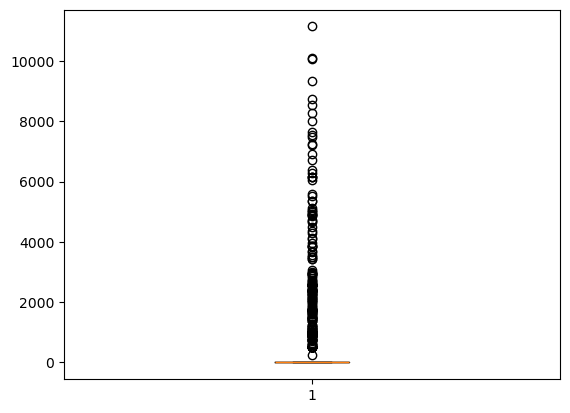

In [538]:
# data_box=data_cleaned3.dropna()
data_box=df1.Qual_miles
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [540]:
Q1 = df1['Qual_miles'].quantile(0.25)
Q3 = df1['Qual_miles'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['Qual_miles'] >= lower_bound) & (df1['Qual_miles'] <= upper_bound)]

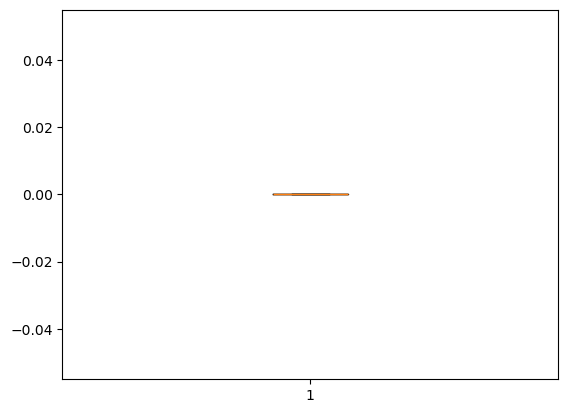

In [542]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Qual_miles
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [377]:
df1['Qual_miles'].describe()

count     3999.000000
mean       144.114529
std        773.663804
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      11148.000000
Name: Qual_miles, dtype: float64

In [378]:
df_n['Qual_miles'].describe()

count    3773.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Qual_miles, dtype: float64

In [544]:
df_n.head(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
1,28143,0,1,1,1,174,1,0,0,7000,0
2,19244,0,1,1,1,215,2,0,0,6968,0


In [546]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.773000e+03,3773.0,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000,3773.000000
mean,7.004041e+04,0.0,2.051948,1.014842,1.012457,16724.284389,11.363371,384.582560,1.144977,4104.294726,0.353830
std,9.279927e+04,0.0,1.368853,0.148489,0.198359,23786.265144,9.368343,1143.989449,3.204571,2064.892797,0.478221
min,0.000000e+00,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,1.803500e+04,0.0,1.000000,1.000000,1.000000,1188.000000,3.000000,0.000000,0.000000,2320.000000,0.000000
50%,4.099400e+04,0.0,1.000000,1.000000,1.000000,6783.000000,12.000000,0.000000,0.000000,4051.000000,0.000000
75%,8.891800e+04,0.0,3.000000,1.000000,1.000000,23503.000000,16.000000,250.000000,1.000000,5778.000000,1.000000
max,1.704838e+06,0.0,5.000000,3.000000,5.000000,263685.000000,68.000000,16675.000000,53.000000,8296.000000,1.000000


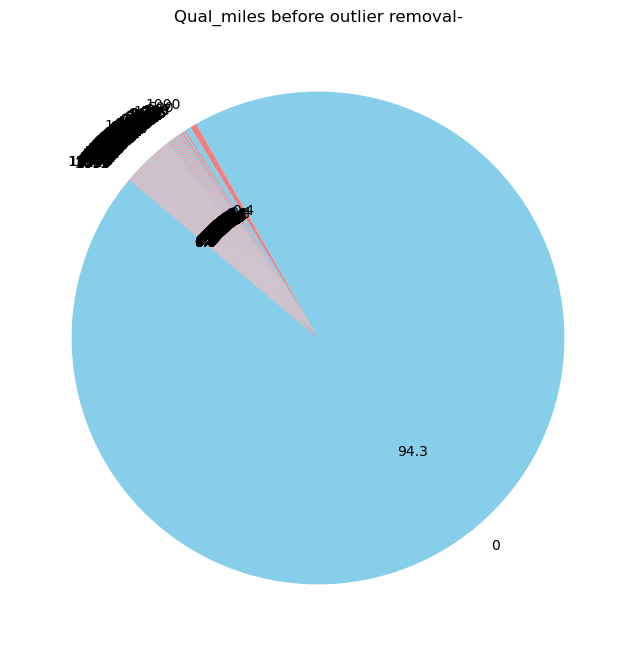

In [379]:
category_counts=df1['Qual_miles'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('Qual_miles before outlier removal-')
plt.show()

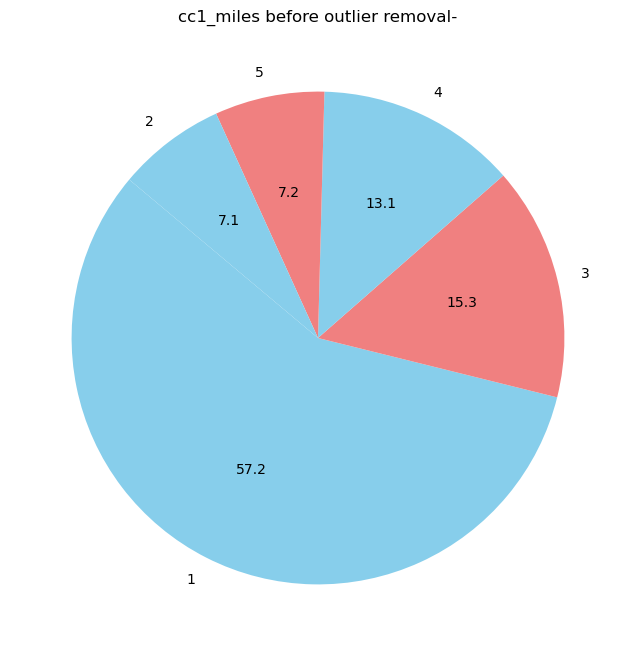

In [380]:
category_counts=df1['cc1_miles'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('cc1_miles before outlier removal-')
plt.show()

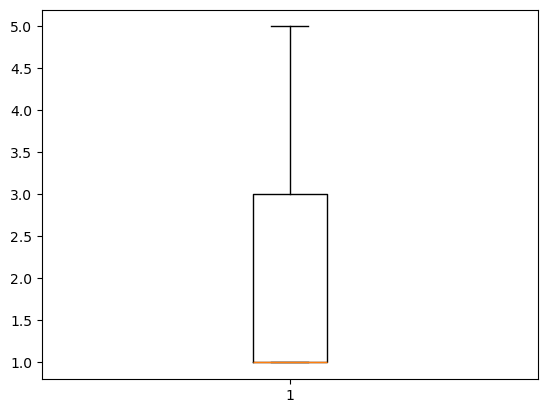

In [381]:

# data_box=data_cleaned3.dropna()
data_box=df1.cc1_miles
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

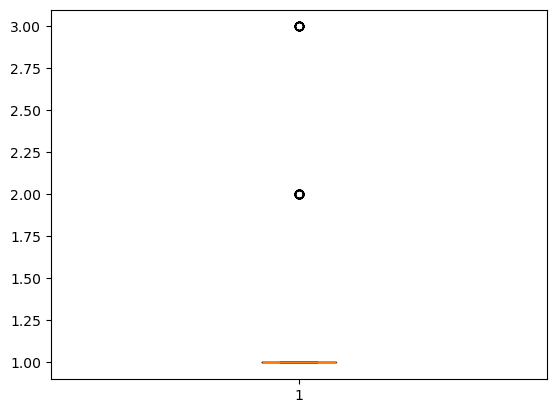

In [382]:

data_box=df1.cc2_miles
b=plt.boxplot(data_box)


In [548]:
Q1 = df1['cc2_miles'].quantile(0.25)
Q3 = df1['cc2_miles'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['cc2_miles'] >= lower_bound) & (df1['cc2_miles'] <= upper_bound)]

In [550]:
df1.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [552]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.956000e+03,3956.000000,3956.000000,3956.0,3956.000000,3956.000000,3956.000000,3956.000000,3956.000000,3956.000000,3956.000000
mean,7.365268e+04,145.428210,2.069515,1.0,1.012386,17171.531092,11.537412,458.723458,1.364510,4120.185794,0.370071
std,1.008059e+05,777.596211,1.379815,0.0,0.196295,24246.592061,9.592104,1401.912030,3.779925,2066.607260,0.482884
min,0.000000e+00,0.000000,1.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,1.853675e+04,0.000000,1.000000,1.0,1.000000,1250.000000,3.000000,0.000000,0.000000,2329.000000,0.000000
50%,4.327000e+04,0.000000,1.000000,1.0,1.000000,7050.000000,12.000000,0.000000,0.000000,4101.500000,0.000000
75%,9.253750e+04,0.000000,3.000000,1.0,1.000000,23935.000000,16.000000,308.500000,1.000000,5793.250000,1.000000
max,1.704838e+06,11148.000000,5.000000,1.0,5.000000,263685.000000,86.000000,30817.000000,53.000000,8296.000000,1.000000


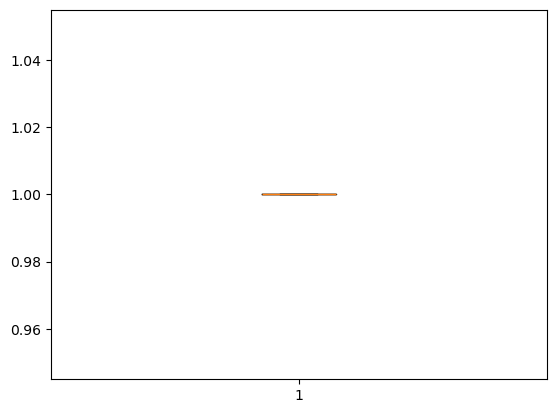

In [384]:

data_box=df_n.cc2_miles
b=plt.boxplot(data_box)


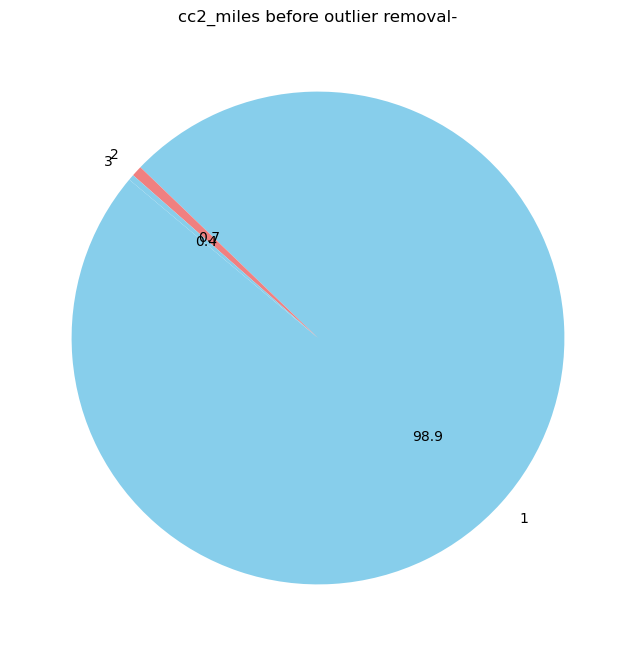

In [554]:
category_counts=df1['cc2_miles'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('cc2_miles before outlier removal-')
plt.show()

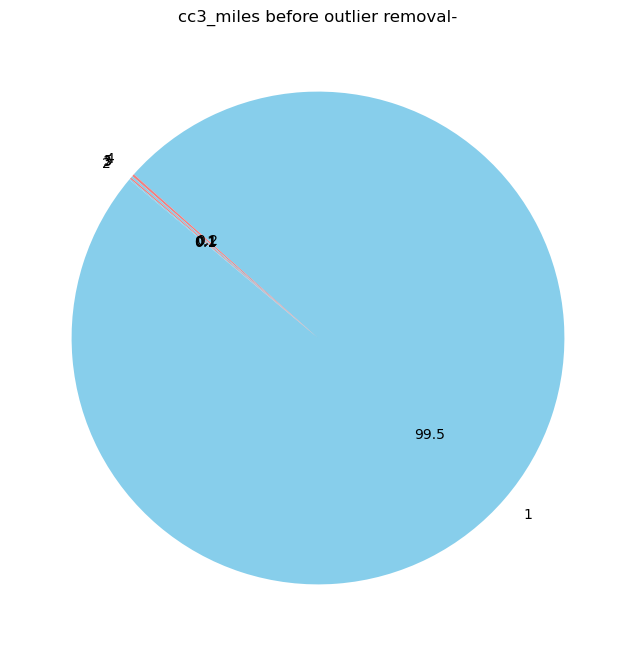

In [556]:
category_counts=df1['cc3_miles'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('cc3_miles before outlier removal-')
plt.show()

In [560]:
Q1 = df1['cc3_miles'].quantile(0.25)
Q3 = df1['cc3_miles'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['cc3_miles'] >= lower_bound) & (df1['cc3_miles'] <= upper_bound)]

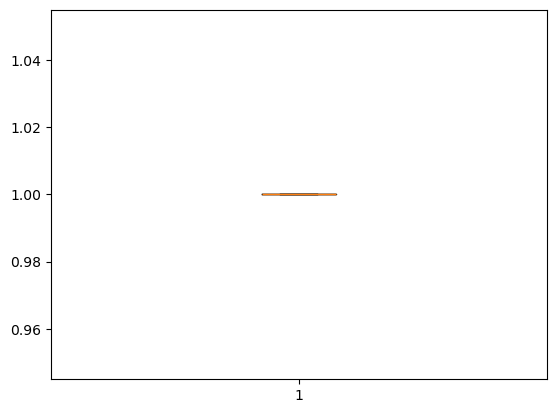

In [388]:
data_box=df_n.cc3_miles
b=plt.boxplot(data_box)


In [566]:
df1.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [568]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.981000e+03,3981.000000,3981.000000,3981.000000,3981.0,3981.000000,3981.000000,3981.000000,3981.000000,3981.000000,3981.000000
mean,7.334654e+04,144.469229,2.053504,1.014569,1.0,16832.344135,11.535795,460.226827,1.373775,4116.885456,0.369756
std,1.004053e+05,775.179480,1.373438,0.147981,0.0,23575.188289,9.552449,1402.572988,3.798036,2066.537392,0.482799
min,0.000000e+00,0.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,1.847600e+04,0.000000,1.000000,1.000000,1.0,1250.000000,3.000000,0.000000,0.000000,2327.000000,0.000000
50%,4.297000e+04,0.000000,1.000000,1.000000,1.0,7100.000000,12.000000,0.000000,0.000000,4096.000000,0.000000
75%,9.193900e+04,0.000000,3.000000,1.000000,1.0,23600.000000,16.000000,300.000000,1.000000,5790.000000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,1.0,263685.000000,86.000000,30817.000000,53.000000,8296.000000,1.000000


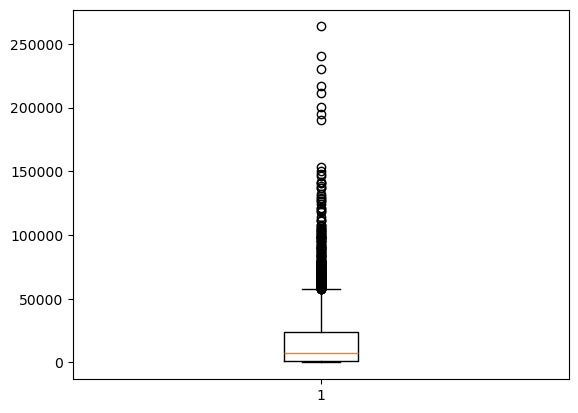

In [570]:
# data_box=data_cleaned3.dropna()
data_box=df1.Bonus_miles
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [572]:
Q1 = df1['Bonus_miles'].quantile(0.25)
Q3 = df1['Bonus_miles'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['Bonus_miles'] >= lower_bound) & (df1['Bonus_miles'] <= upper_bound)]

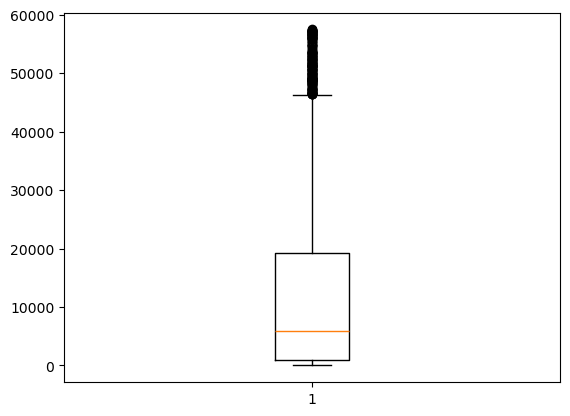

In [574]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Bonus_miles
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [578]:
df1.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [576]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.719000e+03,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000,3719.000000
mean,6.579763e+04,138.429148,1.852917,1.015058,1.002689,12232.364076,10.647217,401.315945,1.213767,4033.403334,0.339070
std,8.828154e+04,772.745595,1.182687,0.149553,0.080299,14386.869787,8.777648,1176.394592,3.369525,2055.652431,0.473457
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,1.753650e+04,0.000000,1.000000,1.000000,1.000000,1012.500000,3.000000,0.000000,0.000000,2264.500000,0.000000
50%,3.923300e+04,0.000000,1.000000,1.000000,1.000000,5824.000000,11.000000,0.000000,0.000000,3958.000000,0.000000
75%,8.231100e+04,0.000000,3.000000,1.000000,1.000000,19174.000000,16.000000,250.000000,1.000000,5671.000000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,4.000000,57505.000000,65.000000,16675.000000,53.000000,8296.000000,1.000000


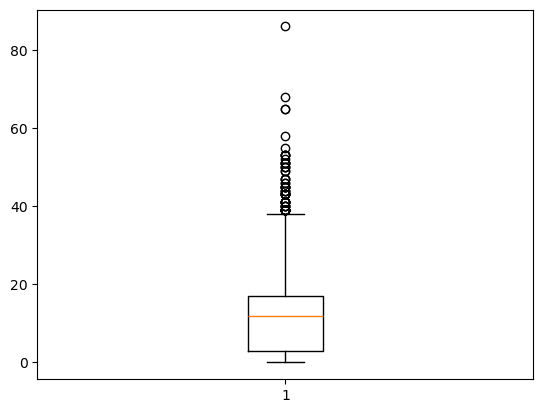

In [392]:
# data_box=data_cleaned3.dropna()
data_box=df1.Bonus_trans
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [393]:
Q1 = df1['Bonus_trans'].quantile(0.25)
Q3 = df1['Bonus_trans'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['Bonus_trans'] >= lower_bound) & (df1['Bonus_trans'] <= upper_bound)]

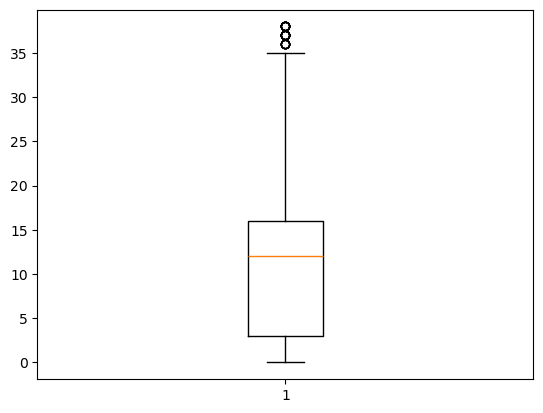

In [394]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Bonus_trans
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

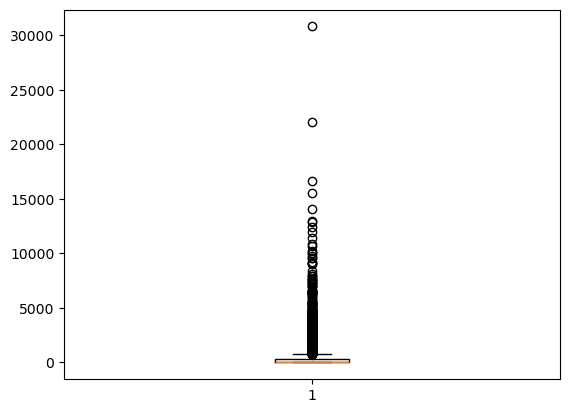

In [395]:
# data_box=data_cleaned3.dropna()
data_box=df1.Flight_miles_12mo
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [396]:
Q1 = df1['Flight_miles_12mo'].quantile(0.25)
Q3 = df1['Flight_miles_12mo'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['Flight_miles_12mo'] >= lower_bound) & (df1['Flight_miles_12mo'] <= upper_bound)]

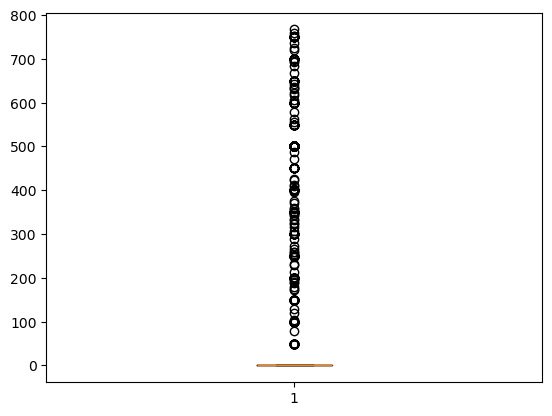

In [397]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Flight_miles_12mo
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

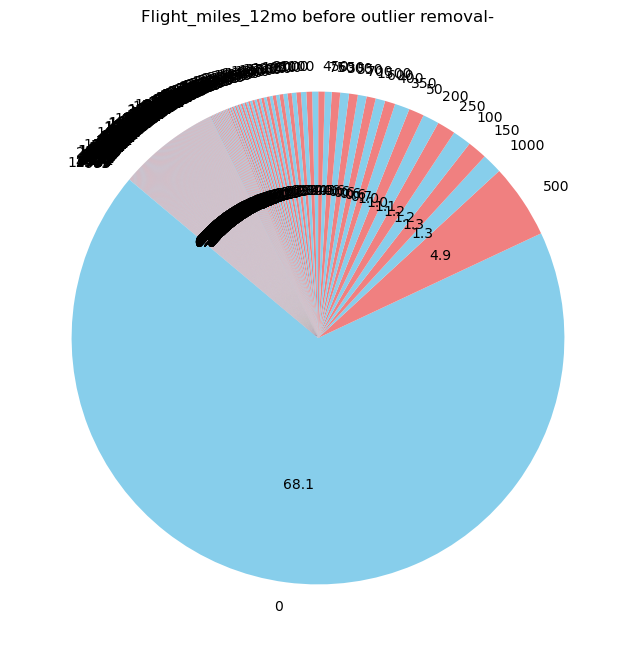

In [398]:
category_counts=df1['Flight_miles_12mo'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('Flight_miles_12mo before outlier removal-')
plt.show()

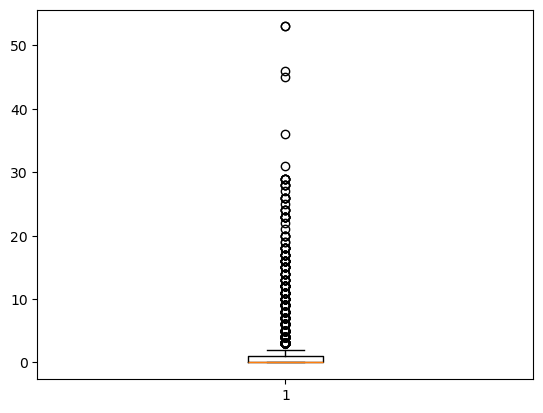

In [399]:
# data_box=data_cleaned3.dropna()
data_box=df1.Flight_trans_12
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [400]:
Q1 = df1['Flight_trans_12'].quantile(0.25)
Q3 = df1['Flight_trans_12'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter the dataframe to keep only values within bounds
df_n = df1[(df1['Flight_trans_12'] >= lower_bound) & (df1['Flight_trans_12'] <= upper_bound)]

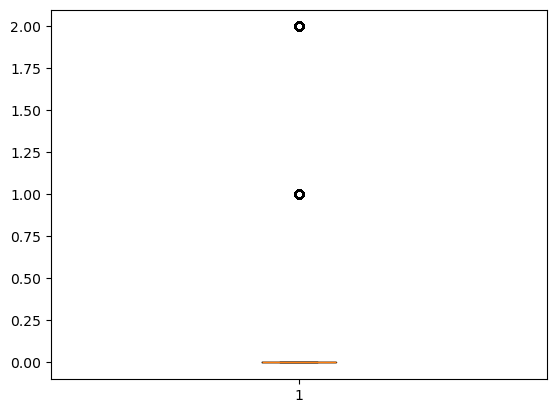

In [401]:
# data_box=data_cleaned3.dropna()
data_box=df_n.Flight_trans_12
b=plt.boxplot(data_box)

#Extracting outliers
# outb=plt.boxplot(df['ALTV'].dropna())

In [402]:
df1['Flight_trans_12'].describe()

count    3999.000000
mean        1.373593
std         3.793172
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max        53.000000
Name: Flight_trans_12, dtype: float64

In [403]:
df_n['Flight_trans_12'].describe()

count    3434.000000
mean        0.277519
std         0.584419
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: Flight_trans_12, dtype: float64

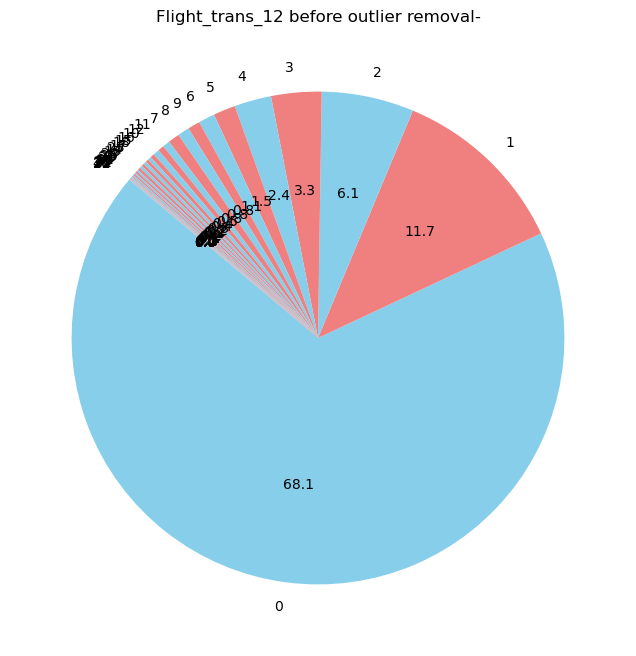

In [404]:
category_counts=df1['Flight_trans_12'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(category_counts.values, labels= category_counts.index, autopct ="%1.1f", startangle=140, colors=['skyblue','lightcoral'])
plt.title('Flight_trans_12 before outlier removal-')
plt.show()

In [405]:
# df_n

In [406]:
# Capping of outliers

In [407]:
# #Outlier removal


# def remove_outliers(DF, COL):
#     # Calculate Q1 (25th percentile) and Q3 (75th percentile)
#     Q1 = DF[COL].quantile(0.25)
#     Q3 = DF[COL].quantile(0.75)
#     # Calculate the Interquartile Range (IQR)
#     IQR = Q3 - Q1
#     # Define the lower and upper bound for outliers
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     # Remove outliers
#     DF = DF[(DF[COL] >= lower_bound) & (DF[COL] <= upper_bound)]
#     return DF


# # This code is removing more than expected number of data, hence we are not dropping but imputing the outliers

In [408]:
# # Assuming df is your DataFrame
# for col in df1.columns:
#     df1 = remove_outliers(df1, col)

# print("DataFrame after removing outliers:")
# print(df1)


In [409]:
df1[df1.duplicated()]

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
3899,1000,0,1,1,1,0,0,0,0,1597,0


In [410]:
df_n=df1.drop_duplicates()

In [504]:
df_n.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.998000e+03,3998.000000,3998.00000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000,3998.000000
mean,7.361949e+04,144.150575,2.05978,1.014507,1.012256,17149.134567,11.604802,460.170835,1.373937,4119.190095,0.370435
std,1.007817e+05,773.757220,1.37699,0.147669,0.195265,24152.465996,9.603258,1400.365407,3.793585,2065.007629,0.482982
min,0.000000e+00,0.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,1.853425e+04,0.000000,1.00000,1.000000,1.000000,1250.000000,3.000000,0.000000,0.000000,2331.250000,0.000000
50%,4.313800e+04,0.000000,1.00000,1.000000,1.000000,7183.000000,12.000000,0.000000,0.000000,4097.500000,0.000000
75%,9.240500e+04,0.000000,3.00000,1.000000,1.000000,23810.750000,17.000000,313.500000,1.000000,5790.750000,1.000000
max,1.704838e+06,11148.000000,5.00000,3.000000,5.000000,263685.000000,86.000000,30817.000000,53.000000,8296.000000,1.000000


In [608]:
import pandas as pd

# Function to remove outliers using IQR method
def remove_outliers(df):
    for col in df.select_dtypes(include=['float', 'int']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Filter out rows with outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Example usage
df_cleaned = remove_outliers(df1)


In [606]:
df1.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [612]:
df_cleaned.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,1785.000000,1785.0,1785.000000,1785.0,1785.0,1785.000000,1785.000000,1785.0,1785.0,1785.000000,1785.0
mean,42256.208964,0.0,1.545658,1.0,1.0,7131.399440,7.684034,0.0,0.0,3725.681232,0.0
std,40136.422130,0.0,0.955433,0.0,0.0,10483.803374,7.251480,0.0,0.0,2090.799689,0.0
min,68.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.0,0.0,8.000000,0.0
25%,12895.000000,0.0,1.000000,1.0,1.0,100.000000,1.000000,0.0,0.0,1879.000000,0.0
50%,28464.000000,0.0,1.000000,1.0,1.0,2155.000000,6.000000,0.0,0.0,3599.000000,0.0
75%,59797.000000,0.0,2.000000,1.0,1.0,9574.000000,13.000000,0.0,0.0,5352.000000,0.0
max,196922.000000,0.0,4.000000,1.0,1.0,49893.000000,33.000000,0.0,0.0,8296.000000,0.0


In [626]:
df_to_cap=df1.copy()

In [628]:
df_to_cap.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [636]:
columns_to_omit = ['cc1_miles', 'Days_since_enroll', 'Award?']  # Replace with column names you want to omit


for col in df1.columns:
    if col not in columns_to_omit:
        Q1 = df_to_cap[col].quantile(0.25)
        Q3 = df_to_cap[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        # Cap values individually
        df_to_cap[col] = np.clip(df_to_cap[col], lower_bound, upper_bound)

print(df_to_cap)

      Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
ID#                                                                       
1     28143.0           0          1          1          1        174.0   
2     19244.0           0          1          1          1        215.0   
3     41354.0           0          1          1          1       4123.0   
4     14776.0           0          1          1          1        500.0   
5     97752.0           0          4          1          1      43300.0   
...       ...         ...        ...        ...        ...          ...   
4017  18476.0           0          1          1          1       8525.0   
4018  64385.0           0          1          1          1        981.0   
4019  73597.0           0          3          1          1      25447.0   
4020  54899.0           0          1          1          1        500.0   
4021   3016.0           0          1          1          1          0.0   

      Bonus_trans  Fligh

In [632]:
df_to_cap.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,63768.635784,0.0,2.059515,1.0,1.0,15410.730683,11.470618,178.055639,0.591523,4118.55939,0.370343
std,58673.700736,0.0,1.376919,0.0,0.0,18074.733482,9.115104,294.678028,0.944826,2065.13454,0.482957
min,0.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,2.00000,0.000000
25%,18527.500000,0.0,1.000000,1.0,1.0,1250.000000,3.000000,0.000000,0.000000,2330.00000,0.000000
50%,43097.000000,0.0,1.000000,1.0,1.0,7171.000000,12.000000,0.000000,0.000000,4096.00000,0.000000
75%,92404.000000,0.0,3.000000,1.0,1.0,23800.500000,17.000000,311.000000,1.000000,5790.50000,1.000000
max,203218.750000,0.0,5.000000,1.0,1.0,57626.250000,38.000000,777.500000,2.500000,8296.00000,1.000000


In [638]:
df_to_cap.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,63768.635784,0.0,2.059515,1.0,1.0,15410.730683,11.470618,178.055639,0.591523,4118.55939,0.370343
std,58673.700736,0.0,1.376919,0.0,0.0,18074.733482,9.115104,294.678028,0.944826,2065.13454,0.482957
min,0.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,2.00000,0.000000
25%,18527.500000,0.0,1.000000,1.0,1.0,1250.000000,3.000000,0.000000,0.000000,2330.00000,0.000000
50%,43097.000000,0.0,1.000000,1.0,1.0,7171.000000,12.000000,0.000000,0.000000,4096.00000,0.000000
75%,92404.000000,0.0,3.000000,1.0,1.0,23800.500000,17.000000,311.000000,1.000000,5790.50000,1.000000
max,203218.750000,0.0,5.000000,1.0,1.0,57626.250000,38.000000,777.500000,2.500000,8296.00000,1.000000


In [640]:
# --------------------Outlier treatment performed-----------------------------------************----------------------

In [650]:
# Scaling 

In [656]:
df_to_cap['Award?'].value_counts()

Award?
0    2518
1    1481
Name: count, dtype: int64

In [648]:
# Normalization function # use sklearn library norm
def norm_func(i):
    x = (i-i.min())/(i.max()-i.min())
    return x

In [658]:
df_norm = norm_func(df_to_cap.iloc[:,:-1])

In [660]:
df_norm.head(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
ID#,,,,,,,,,,
1,0.138486,NaN,0.0,NaN,NaN,0.003019,0.026316,0.0,0.0,0.843742
2,0.094696,NaN,0.0,NaN,NaN,0.003731,0.052632,0.0,0.0,0.839884


In [662]:
df_norm.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3999.000000,0.0,3999.000000,0.0,0.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,0.313793,NaN,0.264879,NaN,NaN,0.267426,0.301858,0.229010,0.236609,0.496330
std,0.288722,NaN,0.344230,NaN,NaN,0.313655,0.239871,0.379007,0.377931,0.248991
min,0.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.091170,NaN,0.000000,NaN,NaN,0.021692,0.078947,0.000000,0.000000,0.280685
50%,0.212072,NaN,0.000000,NaN,NaN,0.124440,0.315789,0.000000,0.000000,0.493610
75%,0.454702,NaN,0.500000,NaN,NaN,0.413015,0.447368,0.400000,0.400000,0.697914
max,1.000000,NaN,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Standardizing the dataset

In [674]:
from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler

In [676]:
df_to_cap.values

array([[2.814e+04, 0.000e+00, 1.000e+00, ..., 0.000e+00, 7.000e+03,
        0.000e+00],
       [1.924e+04, 0.000e+00, 1.000e+00, ..., 0.000e+00, 6.968e+03,
        0.000e+00],
       [4.135e+04, 0.000e+00, 1.000e+00, ..., 0.000e+00, 7.034e+03,
        0.000e+00],
       ...,
       [7.360e+04, 0.000e+00, 3.000e+00, ..., 0.000e+00, 1.402e+03,
        1.000e+00],
       [5.490e+04, 0.000e+00, 1.000e+00, ..., 1.000e+00, 1.401e+03,
        0.000e+00],
       [3.016e+03, 0.000e+00, 1.000e+00, ..., 0.000e+00, 1.398e+03,
        0.000e+00]])

In [678]:
df_std=df_to_cap.values
scaler = MinMaxScaler(feature_range=(0,1))
rescaledX = scaler.fit_transform(df_value)

# Transformed data

set_printoptions(precision=3)
print (rescaledX[0:5,:]) # First 5 rows and all columns of the normalized data will be printed

[[0.138 0.    0.    0.    0.    0.003 0.026 0.    0.    0.844 0.   ]
 [0.095 0.    0.    0.    0.    0.004 0.053 0.    0.    0.84  0.   ]
 [0.203 0.    0.    0.    0.    0.072 0.105 0.    0.    0.848 0.   ]
 [0.073 0.    0.    0.    0.    0.009 0.026 0.    0.    0.838 0.   ]
 [0.481 0.    0.75  0.    0.    0.751 0.684 1.    1.    0.836 1.   ]]


In [680]:
rescaledX

array([[0.138, 0.   , 0.   , ..., 0.   , 0.844, 0.   ],
       [0.095, 0.   , 0.   , ..., 0.   , 0.84 , 0.   ],
       [0.203, 0.   , 0.   , ..., 0.   , 0.848, 0.   ],
       ...,
       [0.362, 0.   , 0.5  , ..., 0.   , 0.169, 1.   ],
       [0.27 , 0.   , 0.   , ..., 0.4  , 0.169, 0.   ],
       [0.015, 0.   , 0.   , ..., 0.   , 0.168, 0.   ]])

In [682]:
df_norm = pd.DataFrame(rescaledX, columns=df_to_cap.columns, index=df_to_cap.index)

In [684]:
df_norm

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,,,,,,
1,0.138486,0.0,0.00,0.0,0.0,0.003019,0.026316,0.000000,0.0,0.843742,0.0
2,0.094696,0.0,0.00,0.0,0.0,0.003731,0.052632,0.000000,0.0,0.839884,0.0
3,0.203495,0.0,0.00,0.0,0.0,0.071547,0.105263,0.000000,0.0,0.847842,0.0
4,0.072710,0.0,0.00,0.0,0.0,0.008677,0.026316,0.000000,0.0,0.837955,0.0
5,0.481019,0.0,0.75,0.0,0.0,0.751394,0.684211,1.000000,1.0,0.835905,1.0
...,...,...,...,...,...,...,...,...,...,...,...
4017,0.090917,0.0,0.00,0.0,0.0,0.147936,0.105263,0.257235,0.4,0.168917,1.0
4018,0.316826,0.0,0.00,0.0,0.0,0.017023,0.131579,0.000000,0.0,0.167953,1.0
4019,0.362157,0.0,0.50,0.0,0.0,0.441587,0.210526,0.000000,0.0,0.168797,1.0


In [686]:
df_norm.isnull().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [ ]:
# Standardization succesfully completed

# 2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

In [690]:
df_norm.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,0.313793,0.0,0.264879,0.0,0.0,0.267426,0.301858,0.229010,0.236609,0.496330,0.370343
std,0.288722,0.0,0.344230,0.0,0.0,0.313655,0.239871,0.379007,0.377931,0.248991,0.482957
min,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.091170,0.0,0.000000,0.0,0.0,0.021692,0.078947,0.000000,0.000000,0.280685,0.000000
50%,0.212072,0.0,0.000000,0.0,0.0,0.124440,0.315789,0.000000,0.000000,0.493610,0.000000
75%,0.454702,0.0,0.500000,0.0,0.0,0.413015,0.447368,0.400000,0.400000,0.697914,1.000000
max,1.000000,0.0,1.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


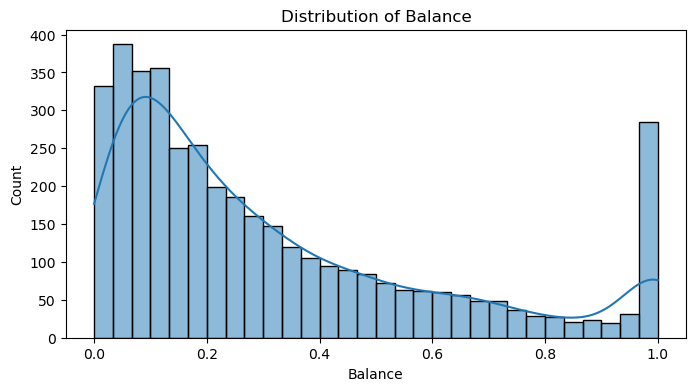

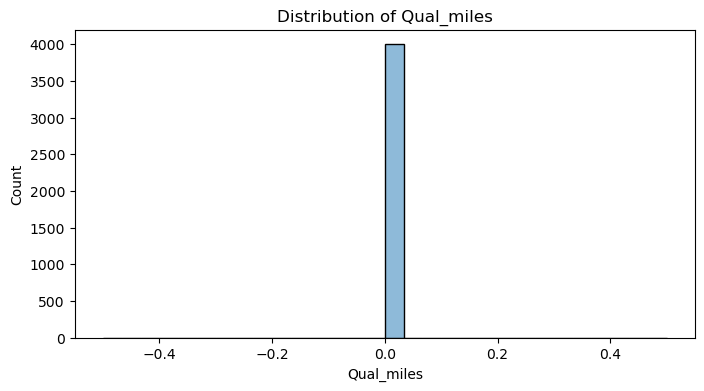

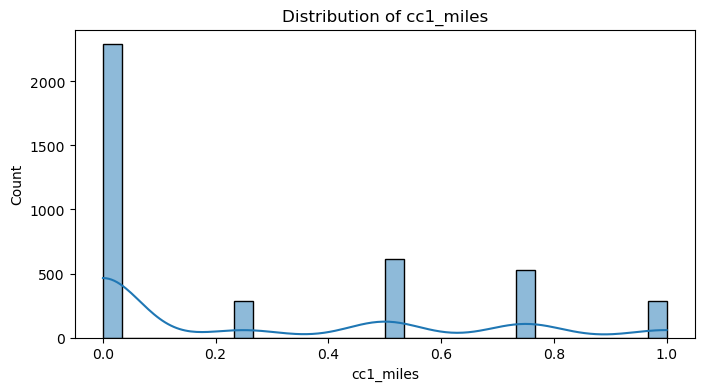

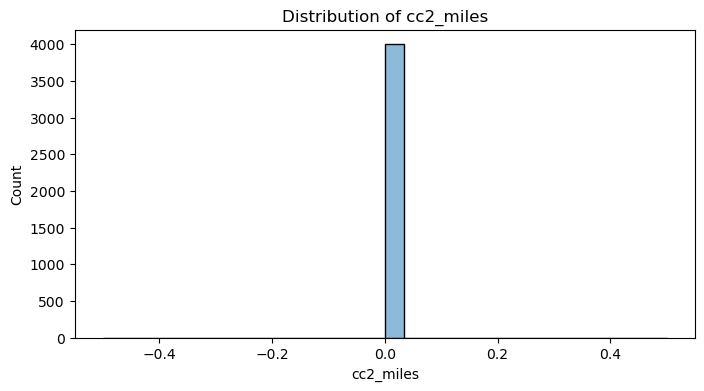

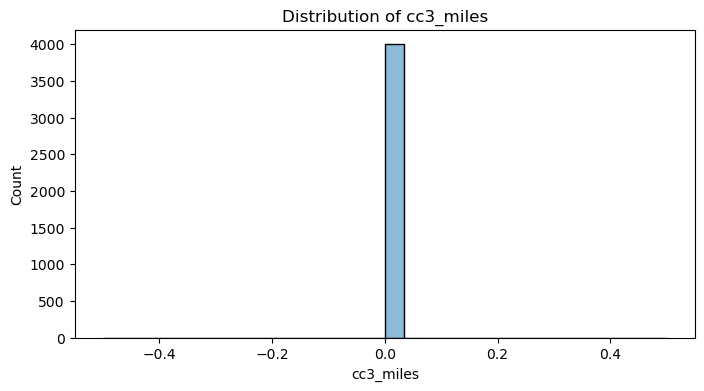

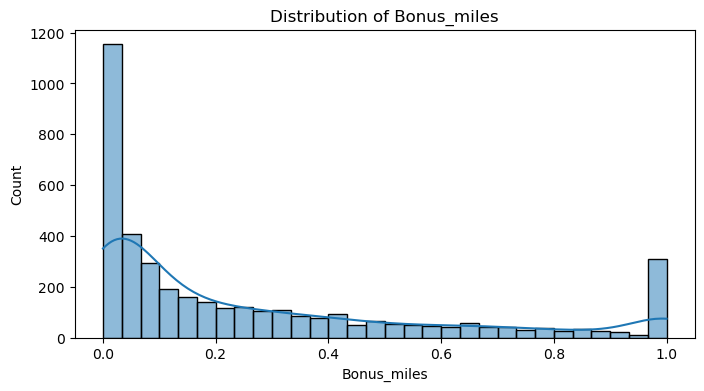

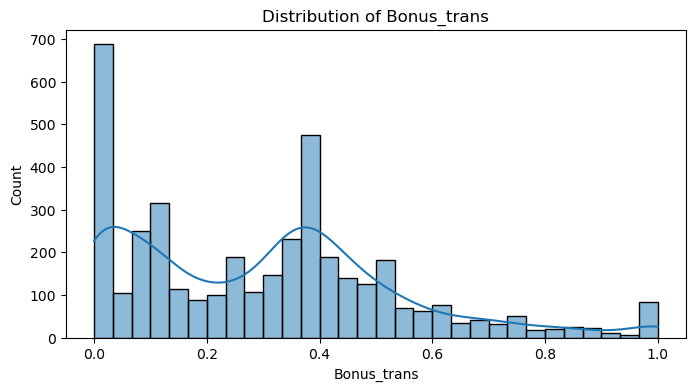

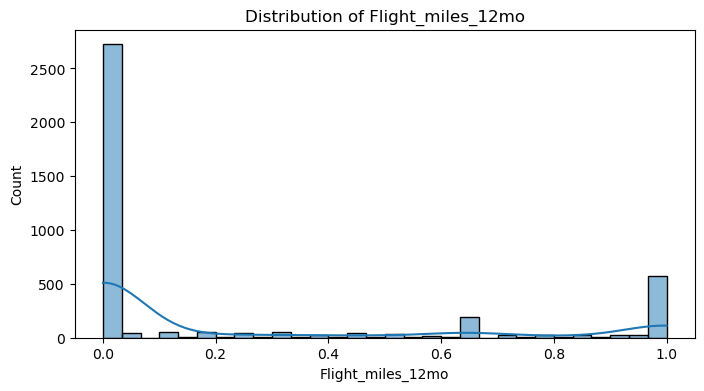

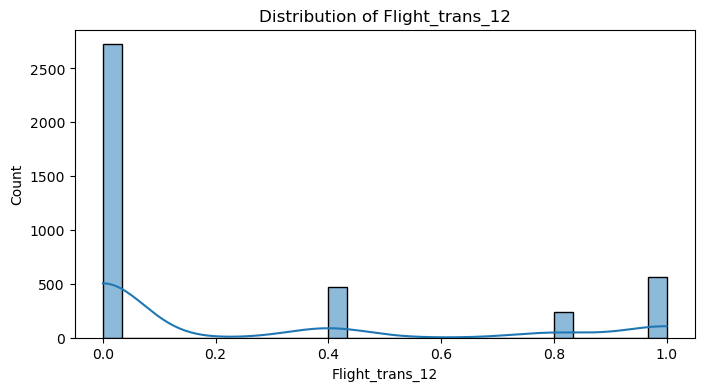

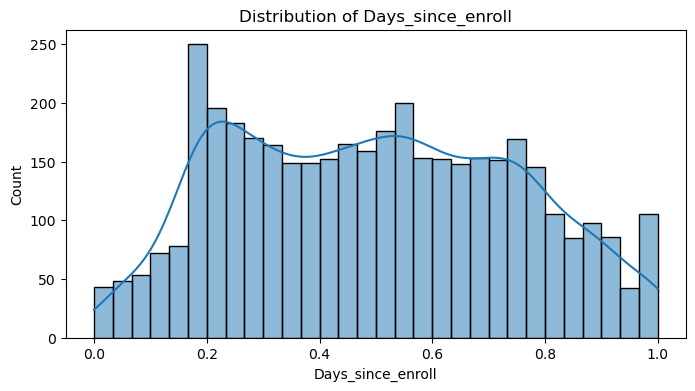

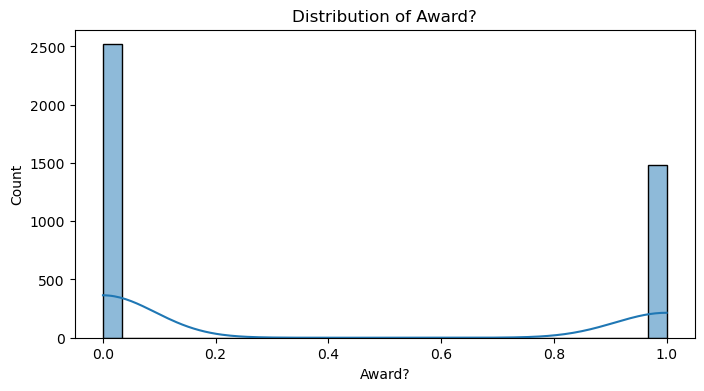

In [692]:
for col in df_norm.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_norm[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

In [694]:
# Check Correlations:
# Use a correlation heatmap to identify relationships between variables.

In [696]:
# Correlation analysis

corr_chart=df_norm.corr()
corr_chart

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Balance,1.000000,NaN,0.446510,NaN,NaN,0.494422,0.409017,0.297045,0.295565,0.286143,0.170678
Qual_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc1_miles,0.446510,NaN,1.000000,NaN,NaN,0.912531,0.627786,0.098786,0.087618,0.230849,0.335457
cc2_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc3_miles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bonus_miles,0.494422,NaN,0.912531,NaN,NaN,1.000000,0.663558,0.205801,0.193669,0.217320,0.394061
Bonus_trans,0.409017,NaN,0.627786,NaN,NaN,0.663558,1.000000,0.310543,0.308518,0.170308,0.337444
Flight_miles_12mo,0.297045,NaN,0.098786,NaN,NaN,0.205801,0.310543,1.000000,0.942734,0.095019,0.293119
Flight_trans_12,0.295565,NaN,0.087618,NaN,NaN,0.193669,0.308518,0.942734,1.000000,0.091898,0.300085
Days_since_enroll,0.286143,NaN,0.230849,NaN,NaN,0.217320,0.170308,0.095019,0.091898,1.000000,0.188121


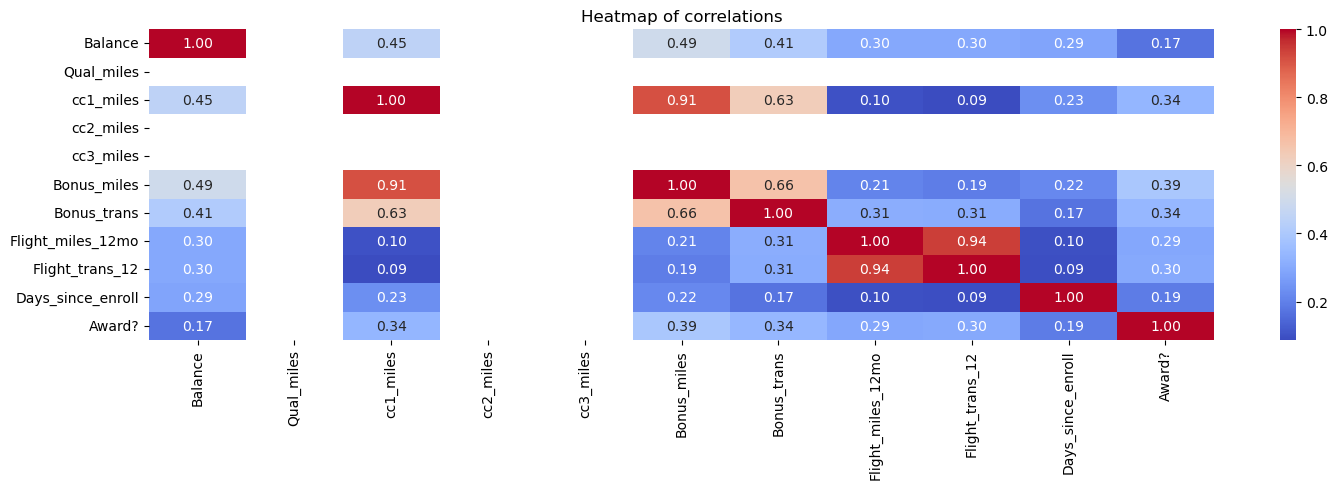

In [698]:
import seaborn as sns
plt.figure(figsize=(15, 5))
sns.heatmap(corr_chart, annot=True, cmap='coolwarm', fmt='.2f')
plt.title ('Heatmap of correlations')
plt.tight_layout()
plt.show()

In [702]:
df_norm['Qual_miles'].value_counts()

Qual_miles
0.0    3999
Name: count, dtype: int64

In [704]:
df_norm['cc2_miles'].value_counts()

cc2_miles
0.0    3999
Name: count, dtype: int64

In [706]:
df_norm['cc3_miles'].value_counts()

cc3_miles
0.0    3999
Name: count, dtype: int64

In [708]:
# These columns can be dropped as the values are constant throughout the rows. Hence this would not contribute to predictability of the model.

In [710]:
# Columns 'cc1_miles' and 'Bonus_miles' are strongly correlated and therefore one of these columns can be removed.
# Keeping 'cc1_miles' because the values in this column are original and not capped during outlier treatment using capping.

In [ ]:
# Columns 'Flight_miles_12mo' and 'Flight_trans_12' are highly correlated and hence one of these columns can be removed. The outlier count was similar for
# both these columns. 'Flight_miles_12mo' removed.

In [712]:
df_cleaned = df_norm.drop(columns=['Qual_miles','cc2_miles','cc3_miles','Bonus_miles','Flight_miles_12mo'])

In [714]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?
ID#,,,,,,
1,0.138486,0.00,0.026316,0.0,0.843742,0.0
2,0.094696,0.00,0.052632,0.0,0.839884,0.0
3,0.203495,0.00,0.105263,0.0,0.847842,0.0
4,0.072710,0.00,0.026316,0.0,0.837955,0.0
5,0.481019,0.75,0.684211,1.0,0.835905,1.0
...,...,...,...,...,...,...
4017,0.090917,0.00,0.105263,0.4,0.168917,1.0
4018,0.316826,0.00,0.131579,0.0,0.167953,1.0
4019,0.362157,0.50,0.210526,0.0,0.168797,1.0


In [ ]:
# Look for potential clusters using pair plots or scatter plots.

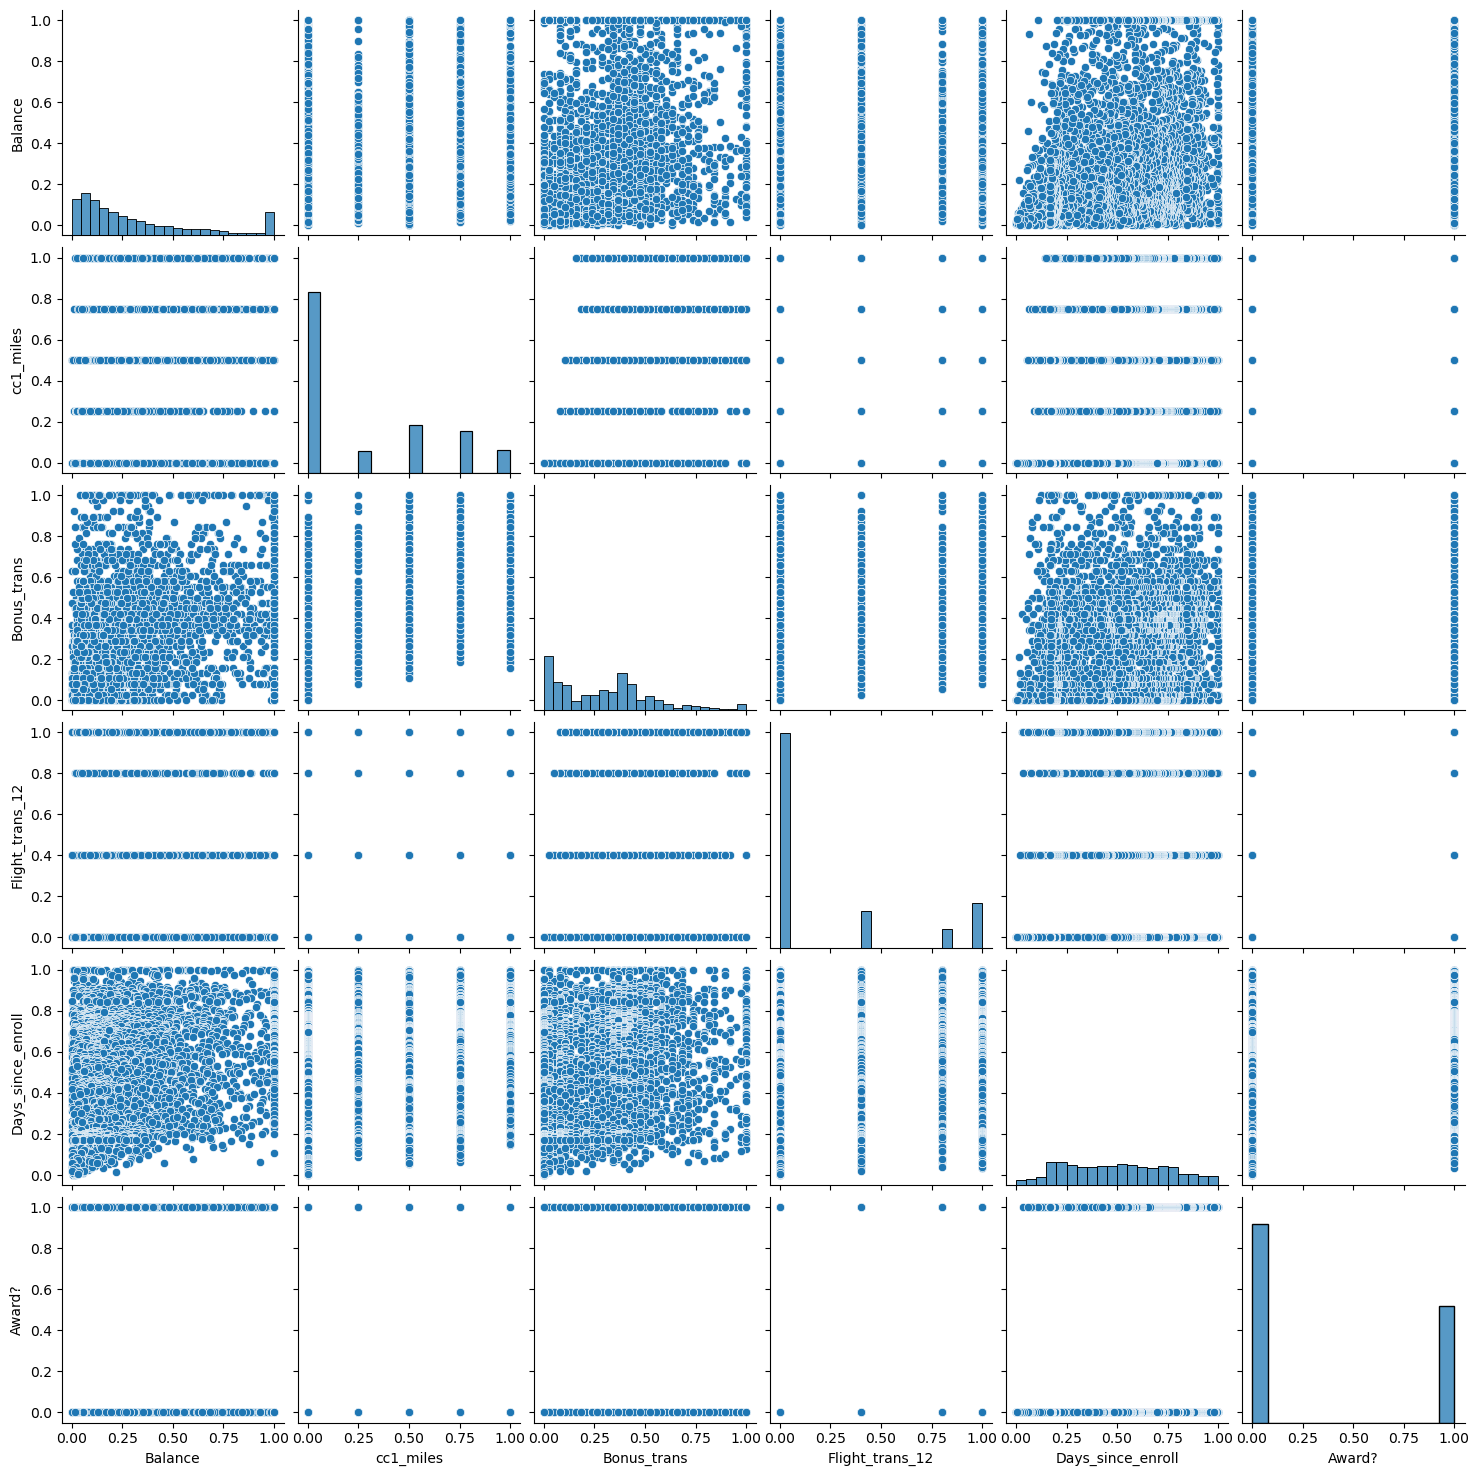

In [718]:
sns.pairplot(df_cleaned)
plt.show()

In [722]:
# sns.pairplot(df_norm)
# plt.show()

In [ ]:
# (Initial Guesswork) : 
# If you already have an idea of which features might cluster together, try plotting two or three features in a 2D or 3D scatter plot:


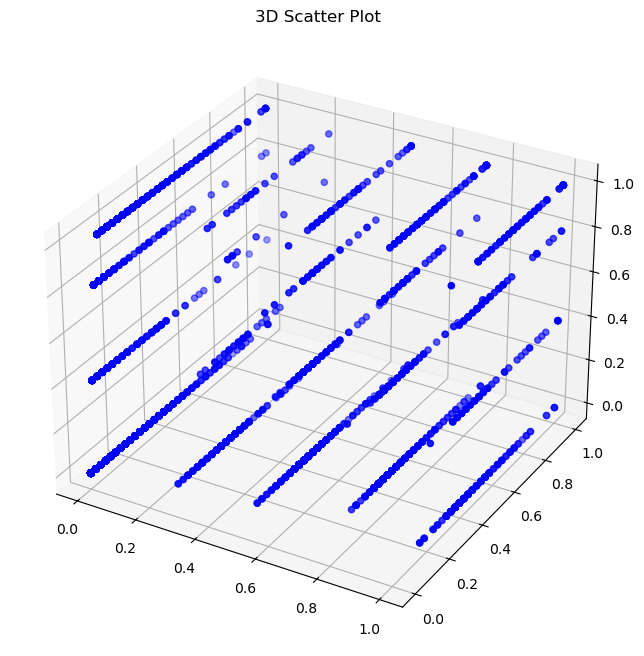

In [746]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_cleaned['cc1_miles'], df_cleaned['Bonus_trans'], df_cleaned['Flight_trans_12'], c='blue', marker='o')
plt.title('3D Scatter Plot')
plt.show()


# 3. Use Visualizations to Understand Hidden Patterns

In [ ]:
# Clustering & Pattern Visualization

In [ ]:
# Starting with K-Means clustering and visualize clusters.

In [748]:
from sklearn.cluster import KMeans

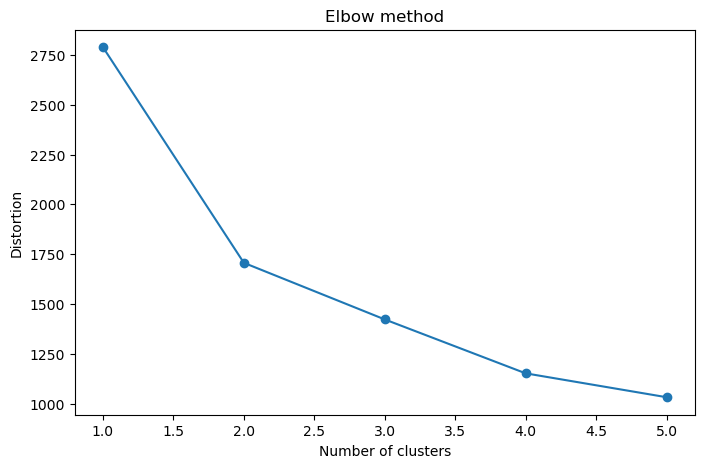

In [750]:
distortions = []
for k in range(1,6):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(df_cleaned)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,6), distortions, marker ='o')

plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.title('Elbow method')
plt.show()

In [752]:
# After detrmining the number of clusters, visualize the clusters


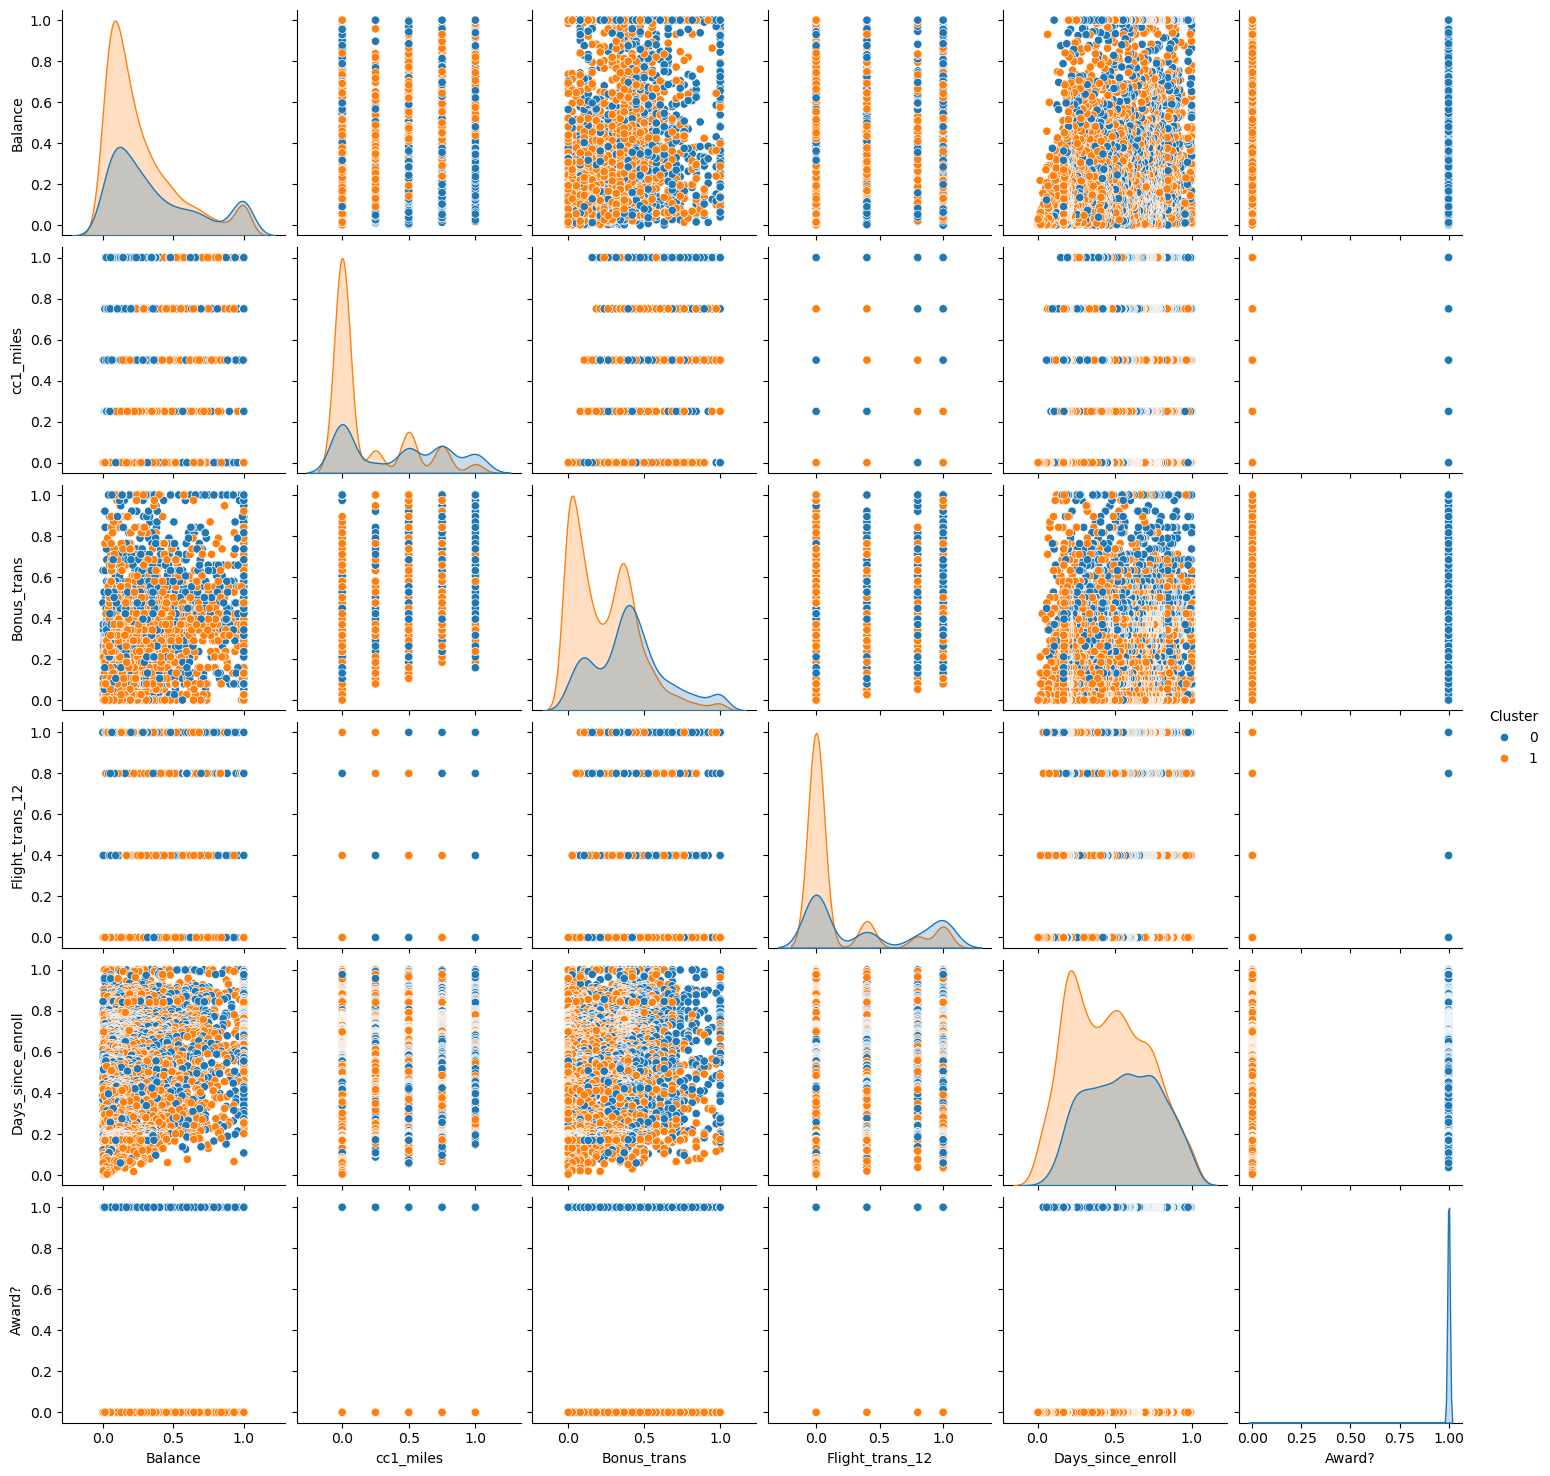

In [754]:
kmeans = KMeans(n_clusters=2,random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(df_cleaned)

sns.pairplot(df_cleaned, hue='Cluster', palette='tab10')
plt.show()

# Implementing Clustering Algorithms:

In [ ]:
# Hierarchical clustering

In [756]:
# import hierarchical clustering libraries
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

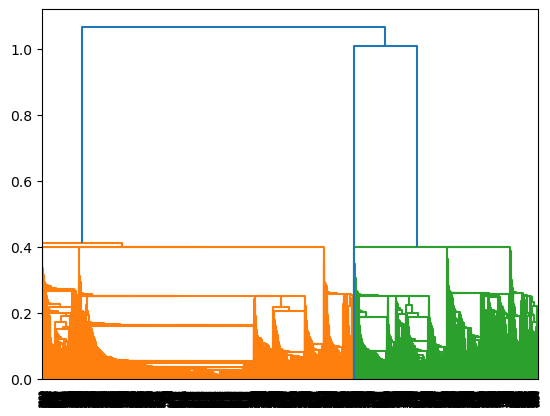

In [758]:
# create dendrogram

dendrogram = sch.dendrogram(sch.linkage(df_cleaned, method='single'))

In [762]:
# Create clusters

hc= AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='single')

In [764]:
hc.fit(df_cleaned)

AgglomerativeClustering(linkage='single')

In [766]:
# Save clusters for chart
y_hc = hc.fit_predict(df_cleaned)

In [768]:
len(y_hc)

3999

In [770]:
df_cleaned['Cluster_ID'] = y_hc

In [772]:
df_cleaned.head(2)

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID
ID#,,,,,,,,
1,0.138486,0.0,0.026316,0.0,0.843742,0.0,1,1
2,0.094696,0.0,0.052632,0.0,0.839884,0.0,1,1


In [774]:
df_cleaned[df_cleaned['Cluster_ID']==1]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID
ID#,,,,,,,,
1,0.138486,0.0,0.026316,0.0,0.843742,0.0,1,1
2,0.094696,0.0,0.052632,0.0,0.839884,0.0,1,1
3,0.203495,0.0,0.105263,0.0,0.847842,0.0,1,1
4,0.072710,0.0,0.026316,0.0,0.837955,0.0,1,1
6,0.080800,0.0,0.000000,0.0,0.836749,0.0,1,1
...,...,...,...,...,...,...,...,...
4014,0.192610,0.5,0.736842,0.0,0.169520,0.0,1,1
4015,0.055020,0.0,0.315789,0.0,0.169400,0.0,1,1
4016,0.019555,0.0,0.078947,0.0,0.168194,0.0,1,1


In [776]:
df_cleaned[df_cleaned['Cluster_ID']==0]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID
ID#,,,,,,,,
5,0.481019,0.75,0.684211,1.0,0.835905,1.0,0,0
8,0.102628,0.00,0.105263,0.4,0.836267,1.0,0,0
9,1.000000,0.50,1.000000,1.0,0.837473,1.0,0,0
10,0.515996,0.50,0.736842,1.0,0.835423,1.0,0,0
12,0.474966,1.00,0.500000,0.0,0.834579,1.0,0,0
...,...,...,...,...,...,...,...,...
4010,0.058720,0.00,0.078947,0.4,0.170002,1.0,0,0
4012,0.012902,0.00,0.157895,0.0,0.169038,1.0,0,0
4017,0.090917,0.00,0.105263,0.4,0.168917,1.0,0,0


In [780]:
df_cleaned=df_cleaned.sort_values('Cluster_ID')
df_cleaned.iloc[:,[0,-1]]

,Balance,Cluster_ID
ID#,,
2016,1.000000,0
430,0.579966,0
431,0.584808,0
433,1.000000,0
475,0.406104,0
...,...,...
3378,0.053765,1
3814,0.239038,1
2949,0.355543,1


In [912]:
# Redoing with 4 clusters



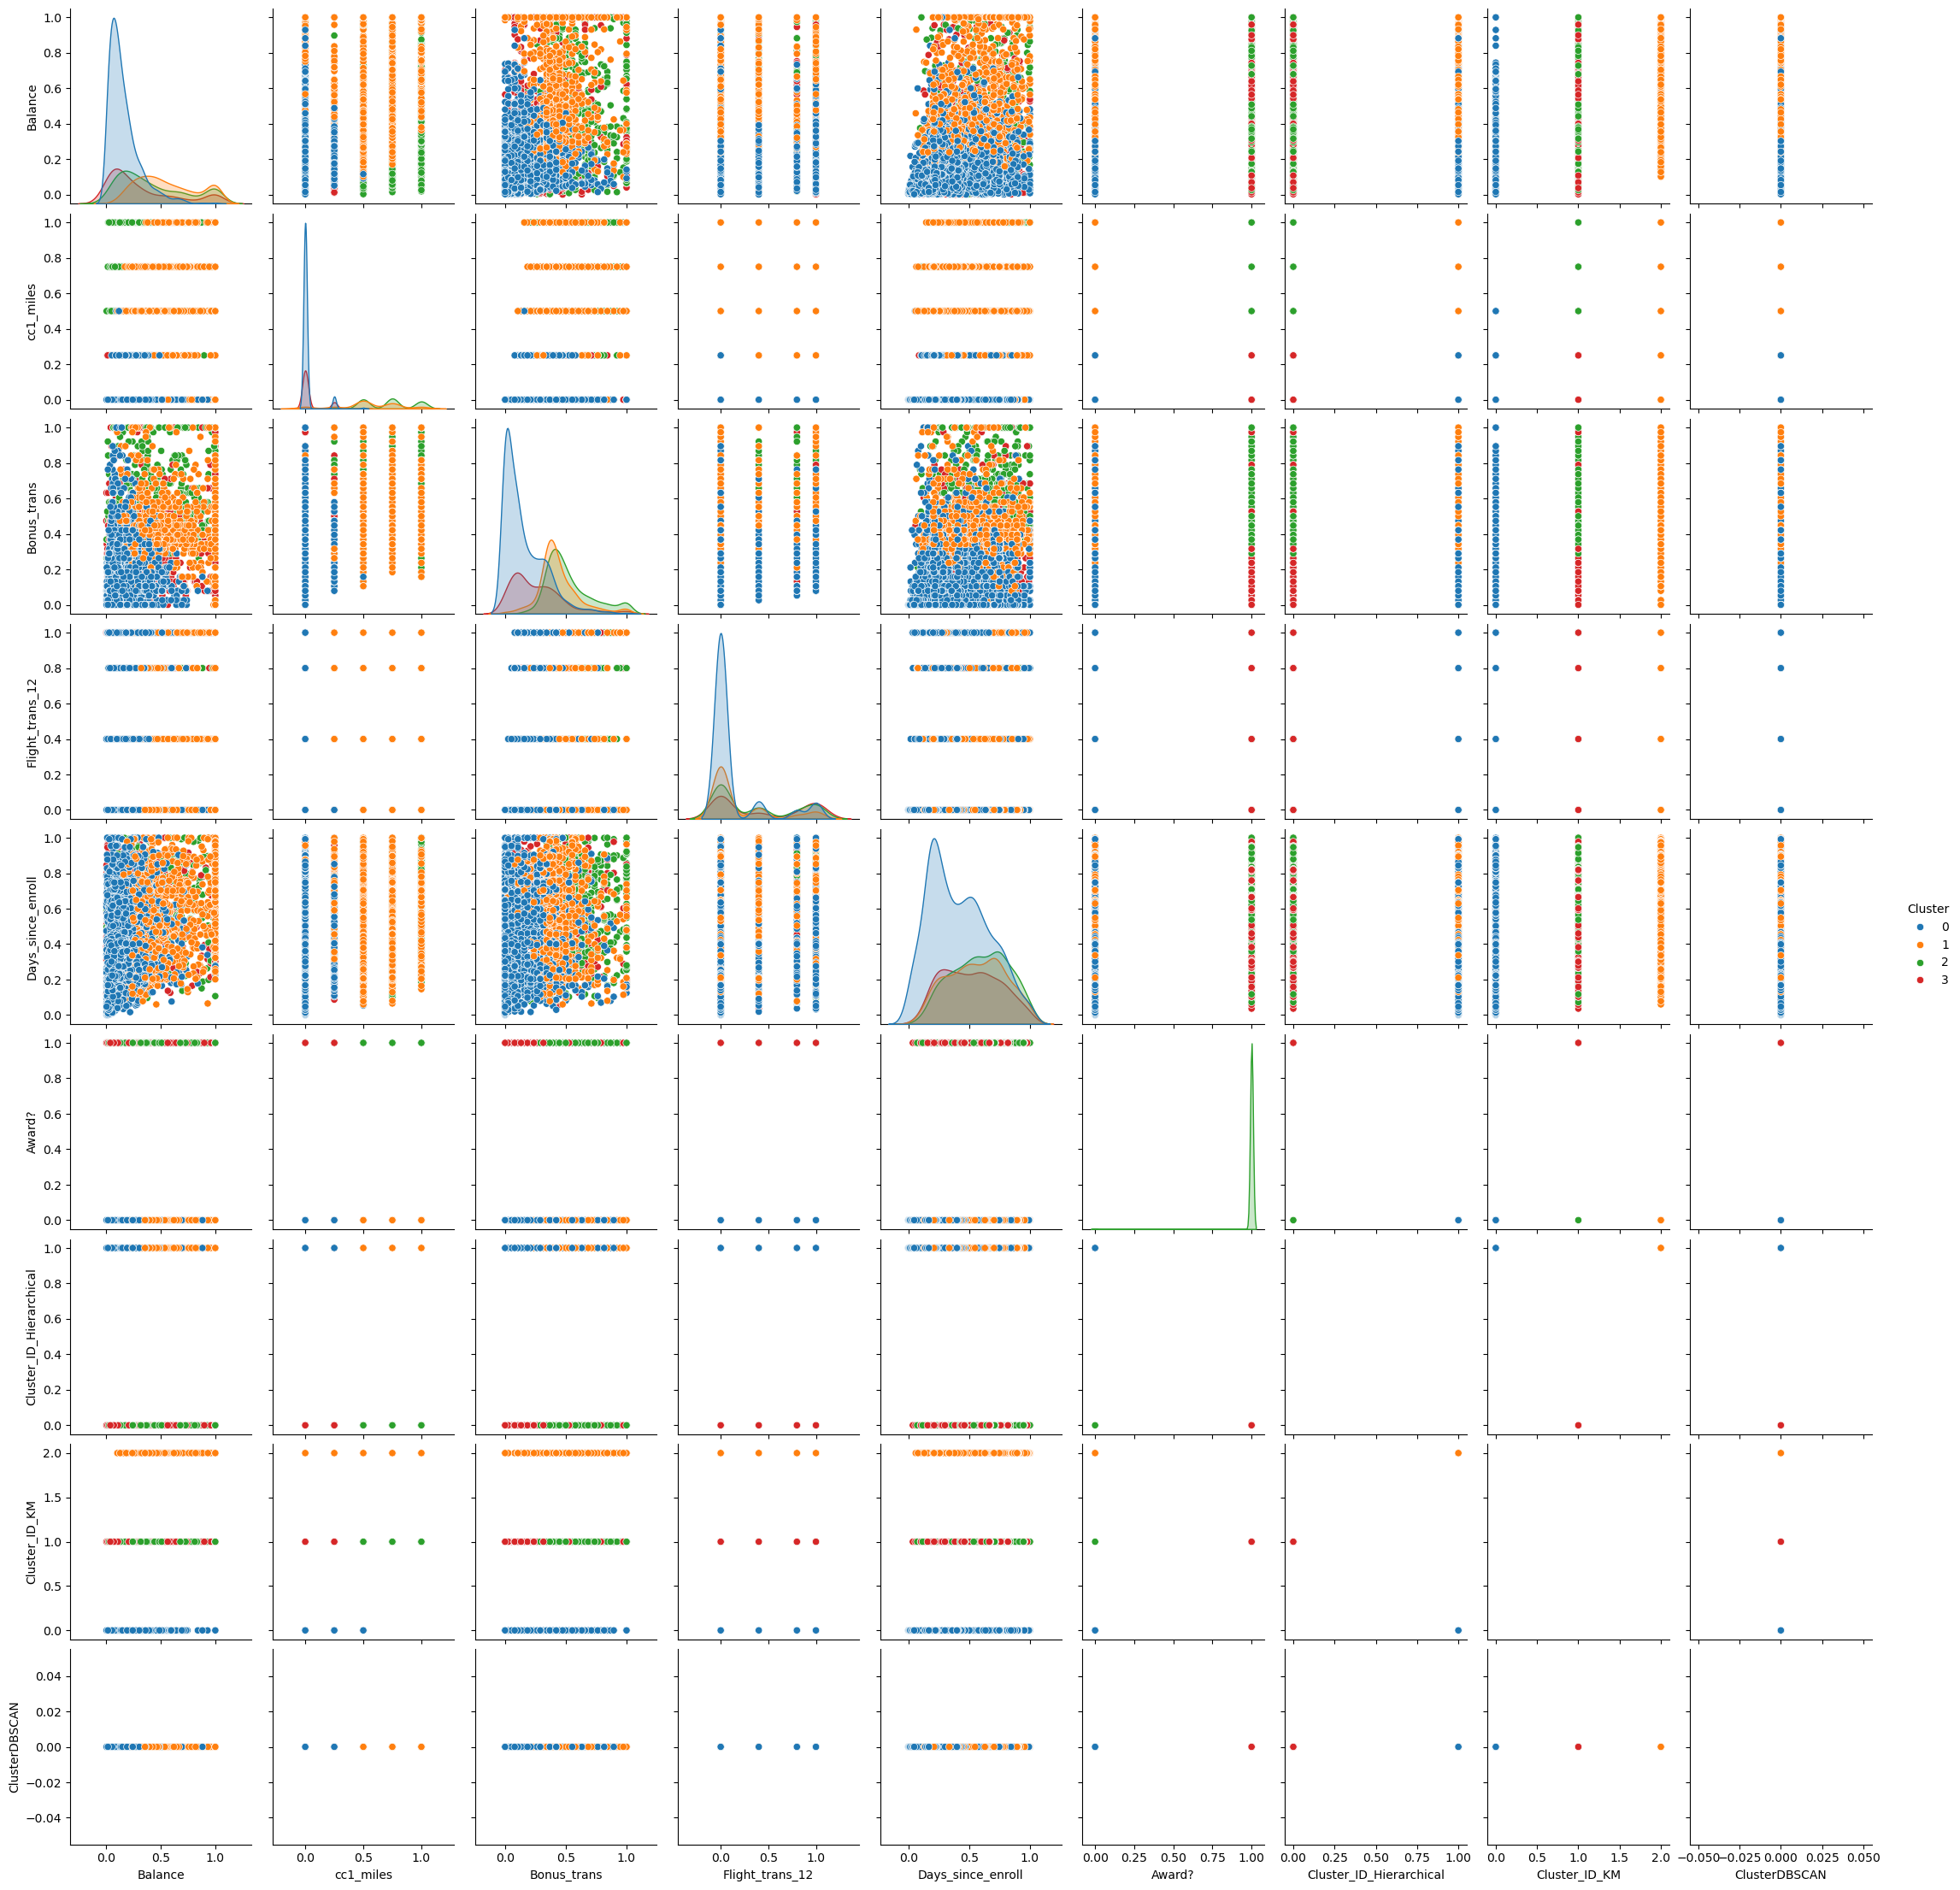

In [914]:
kmeans = KMeans(n_clusters=4,random_state=42)
df_cleaned['Cluster'] = kmeans.fit_predict(df_cleaned)

sns.pairplot(df_cleaned, hue='Cluster', palette='tab10')
plt.show()

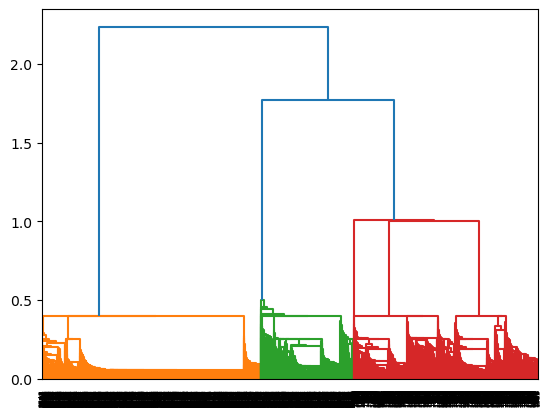

In [916]:
# create dendrogram

dendrogram = sch.dendrogram(sch.linkage(df_cleaned, method='single'))

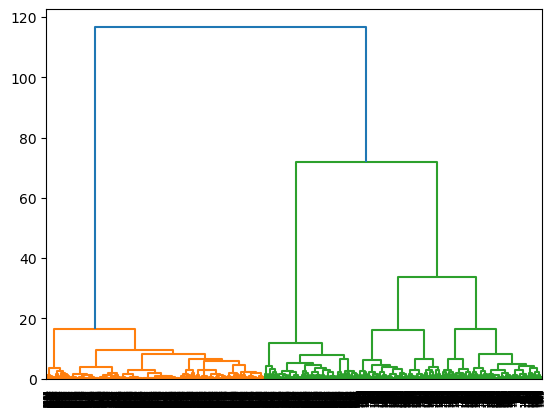

In [920]:
# create dendrogram

dendrogram = sch.dendrogram(sch.linkage(df_cleaned, method='ward'))

In [ ]:
# Another method of hierarchical clustering for k=4

       Balance  cc1_miles  Bonus_trans  Flight_trans_12  Days_since_enroll  \
ID#                                                                          
2016  1.000000       1.00     0.657895              1.0           0.535086   
430   0.579966       1.00     0.394737              0.0           1.000000   
431   0.584808       0.75     0.447368              0.8           0.999156   
433   1.000000       1.00     0.605263              0.8           0.999156   
475   0.406104       0.00     0.131579              1.0           0.991801   

      Award?  Cluster_ID_Hierarchical  Cluster_ID_KM  ClusterDBSCAN  Cluster  \
ID#                                                                            
2016     1.0                        0              1              0        2   
430      1.0                        0              1              0        2   
431      1.0                        0              1              0        2   
433      1.0                        0              1 

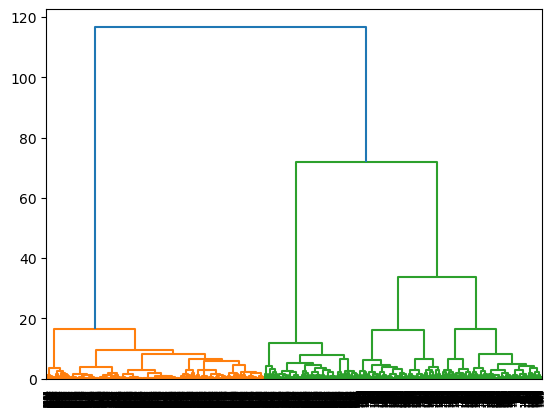

In [922]:
from scipy.cluster.hierarchy import fcluster

# Create the dendrogram
dendrogram = sch.dendrogram(sch.linkage(df_cleaned, method='ward'))

# Generate cluster labels for 4 clusters
cluster_labels = fcluster(sch.linkage(df_cleaned, method='ward'), 4, criterion='maxclust')

# Add the cluster labels to your dataframe
df_cleaned['cluster_id'] = cluster_labels

# Print the first few rows with cluster labels
print(df_cleaned.head())


In [923]:
df_cleaned.head(2)

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM,ClusterDBSCAN,Cluster,cluster_id
ID#,,,,,,,,,,,
2016,1.000000,1.0,0.657895,1.0,0.535086,1.0,0,1,0,2,4
430,0.579966,1.0,0.394737,0.0,1.000000,1.0,0,1,0,2,4


In [ ]:
New columns created -> Cluster and cluster_id for 4 clusters.

In [ ]:
# New Method 

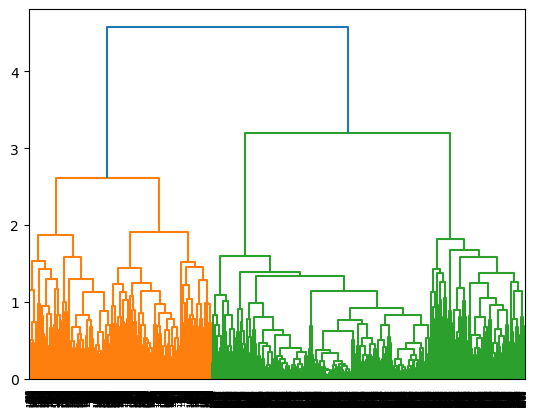

In [926]:
# create dendrogram

dendrogram = sch.dendrogram(sch.linkage(df_cleaned, method='complete'))

# KMeans

In [782]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# How to find optimum number of cluster
# The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster
# sum-of-squares criterion:

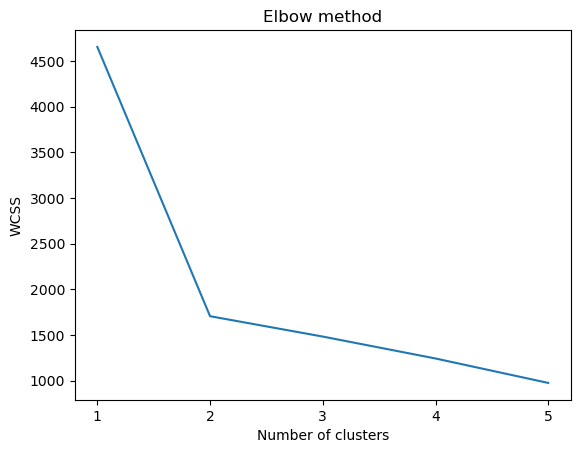

In [784]:
wcss=[]

for i in range(1,6):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(df_cleaned)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,6),wcss)
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1,6))
plt.show()

In [786]:
wcss

[4654.041192891111,
 1706.5202154847468,
 1483.5446592870605,
 1243.6385586644053,
 976.1968642312253]

In [788]:
# High WCSS: Clusters are scattered, and data points are not well grouped.

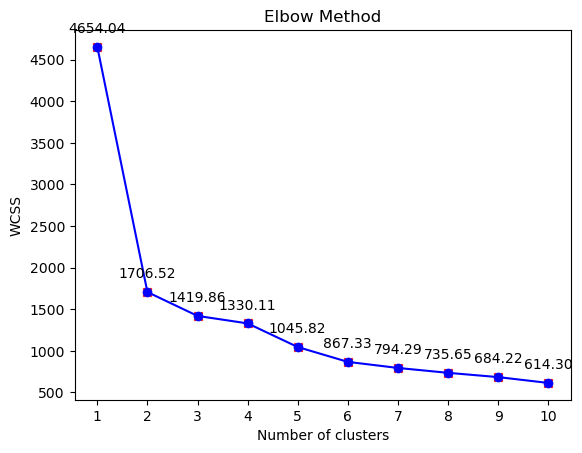

In [790]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df_cleaned)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

# Set x-axis ticks to display all values in the range (1, 11)
plt.xticks(range(1, 11))

# Annotate each point on the plot with its corresponding y-axis value
for i, txt in enumerate(wcss):
    plt.annotate(f'{txt:.2f}', (i+1, txt), textcoords="offset points", xytext=(0,10), ha='center')

# Highlight the points on the plot
plt.scatter(range(1, 11), wcss, c='r', marker='x')

plt.show()

In [792]:
wcss

[4654.041192891111,
 1706.5202154847468,
 1419.8586295958721,
 1330.1052071631375,
 1045.8163878876794,
 867.3271857340164,
 794.2888938919049,
 735.646142671596,
 684.2201272147802,
 614.2991180725213]

In [939]:
kmeans = KMeans(n_clusters=2)
predict=kmeans.fit_predict(df_cleaned)

In [941]:
predict

array([1, 1, 1, ..., 0, 0, 0])

In [943]:
df_cleaned['Cluster_ID_KMeans'] = kmeans.labels_

In [800]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID,Cluster_ID_KMeans
ID#,,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,0,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,0,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,0,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,0,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,1,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,1,0
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,1,0


In [802]:
df_cleaned[df_cleaned['Cluster_ID_KMeans']==0]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID,Cluster_ID_KMeans
ID#,,,,,,,,,
676,0.079033,0.00,0.289474,0.0,0.767302,0.0,1,1,0
670,0.139288,0.00,0.078947,0.0,0.767905,0.0,1,1,0
640,0.089121,0.00,0.684211,0.0,0.778997,0.0,1,1,0
653,0.051590,0.00,0.000000,0.0,0.768387,0.0,1,1,0
641,0.204341,0.00,0.000000,0.0,0.772124,0.0,1,1,0
...,...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,1,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,1,0
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,1,0


In [804]:
df_cleaned[df_cleaned['Cluster_ID_KMeans']==1]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID,Cluster_ID_KMeans
ID#,,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,0,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,0,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,0,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,0,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,0,1
...,...,...,...,...,...,...,...,...,...
2282,0.315684,0.50,0.500000,0.0,0.430793,1.0,0,0,1
2284,0.107465,0.00,0.078947,0.4,0.438389,1.0,0,0,1
2285,0.899051,0.00,0.315789,1.0,0.460333,1.0,0,0,1


In [816]:
#Build Cluster algorithm
from sklearn.cluster import KMeans
clusters_new = KMeans(3)
clusters_new.fit(df_cleaned)

KMeans(n_clusters=3)

In [818]:
clusters_new.labels_

array([1, 1, 1, ..., 2, 0, 0])

In [820]:
#Assign clusters to the data set
df_cleaned['clusterid_new'] = clusters_new.labels_

In [822]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster,Cluster_ID,Cluster_ID_KMeans,clusterid_new
ID#,,,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,0,1,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,0,1,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,0,1,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,0,1,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,1,0,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,1,0,2
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,1,0,2


In [830]:
#these are standardized values.
clusters_new.cluster_centers_

array([[ 1.565e-01,  1.718e-02,  1.538e-01,  1.315e-01,  4.183e-01,
         1.665e-16,  1.000e+00,  1.000e+00, -1.776e-15, -1.776e-15],
       [ 3.782e-01,  4.158e-01,  4.078e-01,  3.849e-01,  5.576e-01,
         9.993e-01, -1.554e-15, -1.554e-15,  1.000e+00,  1.000e+00],
       [ 5.539e-01,  5.460e-01,  4.392e-01,  1.907e-01,  5.578e-01,
        -4.441e-16,  1.000e+00,  1.000e+00,  3.886e-16,  3.886e-16]])

In [834]:
df_cleaned= df_cleaned.drop("Cluster", axis=1)

In [836]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID,Cluster_ID_KMeans,clusterid_new
ID#,,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,1,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,1,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,1,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,1,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,1,1
...,...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,0,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,0,2
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,0,2


In [838]:
df_cleaned= df_cleaned.drop("Cluster_ID_KMeans", axis=1)

In [840]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID,clusterid_new
ID#,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,1
...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,2
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,2


In [842]:
df_cleaned = df_cleaned.rename(columns={'Cluster_ID':'Cluster_ID_Hierarchical'})

In [844]:
df_cleaned = df_cleaned.rename(columns={'clusterid_new':'Cluster_ID_KM'})

In [846]:
df_cleaned

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM
ID#,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,1
...,...,...,...,...,...,...,...,...
3378,0.053765,0.00,0.000000,0.0,0.222932,0.0,1,0
3814,0.239038,0.75,0.421053,0.0,0.336629,0.0,1,2
2949,0.355543,0.75,0.421053,0.0,0.210996,0.0,1,2


In [848]:
df_cleaned.groupby('Cluster_ID_KM').agg(['mean']).reset_index()

,Cluster_ID_KM,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical
,,mean,mean,mean,mean,mean,mean,mean
0,0,0.156602,0.017584,0.153984,0.131367,0.418413,0.000000,1.0
1,1,0.378180,0.415823,0.407770,0.384885,0.557620,0.999325,0.0
2,2,0.554784,0.546419,0.439446,0.191247,0.558046,0.000000,1.0


In [850]:
df_cleaned[df_cleaned['Cluster_ID_KM']==0]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM
ID#,,,,,,,,
676,0.079033,0.0,0.289474,0.0,0.767302,0.0,1,0
670,0.139288,0.0,0.078947,0.0,0.767905,0.0,1,0
640,0.089121,0.0,0.684211,0.0,0.778997,0.0,1,0
653,0.051590,0.0,0.000000,0.0,0.768387,0.0,1,0
641,0.204341,0.0,0.000000,0.0,0.772124,0.0,1,0
...,...,...,...,...,...,...,...,...
2977,0.302502,0.0,0.368421,0.0,0.404148,0.0,1,0
3816,0.191060,0.0,0.000000,0.0,0.360622,0.0,1,0
3378,0.053765,0.0,0.000000,0.0,0.222932,0.0,1,0


In [852]:
df_cleaned[df_cleaned['Cluster_ID_KM']==1]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM
ID#,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,1
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,1
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,1
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,1
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,1
...,...,...,...,...,...,...,...,...
2282,0.315684,0.50,0.500000,0.0,0.430793,1.0,0,1
2284,0.107465,0.00,0.078947,0.4,0.438389,1.0,0,1
2285,0.899051,0.00,0.315789,1.0,0.460333,1.0,0,1


In [862]:
df_cleaned[df_cleaned['Cluster_ID_KM']==2]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM
ID#,,,,,,,,
645,0.345111,0.25,0.421053,0.0,0.770436,0.0,1,2
647,0.406483,0.50,0.394737,0.0,0.773451,0.0,1,2
701,0.520046,0.75,0.447368,0.0,0.766699,0.0,1,2
684,0.655171,0.75,0.368421,0.4,0.769592,0.0,1,2
688,1.000000,0.50,0.342105,0.0,0.763805,0.0,1,2
...,...,...,...,...,...,...,...,...
3846,0.425650,0.75,0.526316,0.0,0.203641,0.0,1,2
2981,0.324409,0.50,0.447368,0.0,0.405112,0.0,1,2
2988,0.396125,0.50,0.421053,0.0,0.379069,0.0,1,2


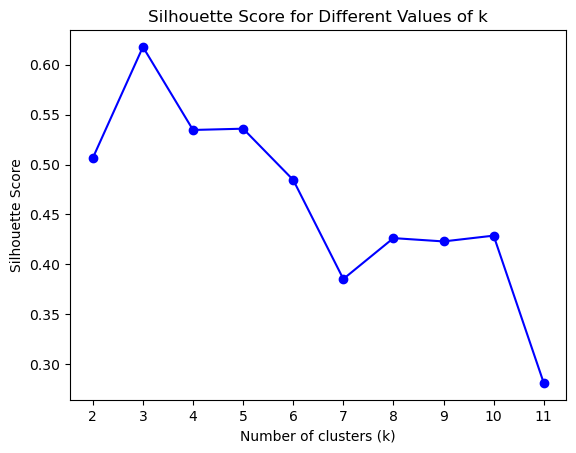

In [858]:

# Assuming you have your scaled data (scaled_Univ_df) ready

# Initialize an empty list to store silhouette scores
silhouette_scores = []

k_range = range(2, 12)

# Calculate silhouette score for each value of k
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df_cleaned)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(df_cleaned, labels)
    silhouette_scores.append(silhouette_avg)

# Plot the silhouette scores
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Score for Different Values of k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()


In [860]:
# The peak silhouette score is at 3, so 3 is the optimum number of clusters

# DBSCAN

In [864]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [866]:
df_cleaned.values

array([[1.   , 1.   , 0.658, ..., 1.   , 0.   , 1.   ],
       [0.58 , 1.   , 0.395, ..., 1.   , 0.   , 1.   ],
       [0.585, 0.75 , 0.447, ..., 1.   , 0.   , 1.   ],
       ...,
       [0.356, 0.75 , 0.421, ..., 0.   , 1.   , 2.   ],
       [0.242, 0.   , 0.421, ..., 0.   , 1.   , 0.   ],
       [0.015, 0.   , 0.   , ..., 0.   , 1.   , 0.   ]])

In [868]:
dbscan = DBSCAN(eps=7, min_samples=7)
dbscan.fit_predict(rescaledX)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [870]:
# Noisy labels are given the label -1.

dbscan.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [872]:
df_cleaned['ClusterDBSCAN']=dbscan.labels_
df_cleaned.head()

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM,ClusterDBSCAN
ID#,,,,,,,,,
2016,1.000000,1.00,0.657895,1.0,0.535086,1.0,0,1,0
430,0.579966,1.00,0.394737,0.0,1.000000,1.0,0,1,0
431,0.584808,0.75,0.447368,0.8,0.999156,1.0,0,1,0
433,1.000000,1.00,0.605263,0.8,0.999156,1.0,0,1,0
475,0.406104,0.00,0.131579,1.0,0.991801,1.0,0,1,0


In [876]:
# Use pandas filtering and get noisy datapoints -1
df_cleaned[df_cleaned['ClusterDBSCAN']==-1]

,Balance,cc1_miles,Bonus_trans,Flight_trans_12,Days_since_enroll,Award?,Cluster_ID_Hierarchical,Cluster_ID_KM,ClusterDBSCAN
ID#,,,,,,,,,


In [878]:
# Silhouette scores

In [904]:
silhouette_scores=[]

# Range of eps values

eps_range=[0.5,1,2,3,4,5,6,7,8,10,11,12,13,14,15]
# eps_range=[0.5,1,2]

# Range of min_samples values

# min_samples_range = [7,10,15,12]
min_samples_range = [3,5,7,8,11,16,18,20]
# min_samples_range=[3,7,25,30]

# Calculate the silhouette score for each combination of eps and min_samples

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps,min_samples=min_samples)
        labels=dbscan.fit_predict(rescaledX)


# Check if there are atleast two unique labels
        if len(np.unique(labels))>=2:
            silhouette_avg = silhouette_score(rescaledX, labels)
            silhouette_scores.append((eps,min_samples,silhouette_avg))


# Find the parameters with the highest silhouette score
best_params = max(silhouette_scores,key=lambda x:x[2])
    
print(f"Best Parameters: eps={best_params[0]}, min_samples={best_params[1]}")
print(f"Silhouette Score: {best_params[2]}")


Best Parameters: eps=1, min_samples=3
Silhouette Score: 0.35544923687092084


In [905]:
best_params

(1, 3, 0.35544923687092084)

In [908]:
silhouette_scores

[(0.5, 3, 0.2753447382465132),
 (0.5, 5, 0.3053373296176538),
 (0.5, 7, 0.30624666385630395),
 (0.5, 8, 0.30758794051816274),
 (0.5, 11, 0.3086967574307635),
 (0.5, 16, 0.30712442392851913),
 (0.5, 18, 0.3076268615273814),
 (0.5, 20, 0.30456764604495545),
 (1, 3, 0.35544923687092084),
 (1, 5, 0.35544923687092084),
 (1, 7, 0.35544923687092084),
 (1, 8, 0.35544923687092084),
 (1, 11, 0.35544923687092084),
 (1, 16, 0.35544923687092084),
 (1, 18, 0.35544923687092084),
 (1, 20, 0.35544923687092084)]

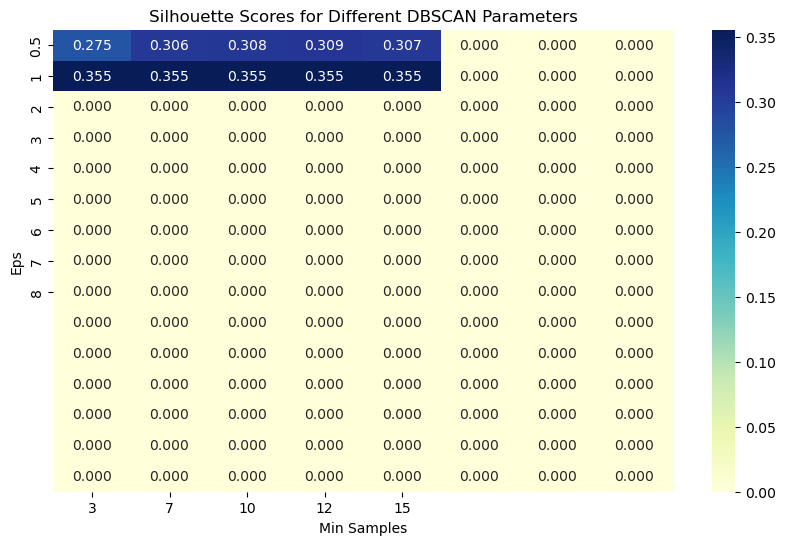

In [910]:

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
# from sklearn.preprocessing import StandardScaler

# Assuming you have your data (X) ready
# X_scaled = StandardScaler().fit_transform(X)

# Initialize an empty array to store silhouette scores
silhouette_scores = np.zeros((len(eps_range), len(min_samples_range)))

# Range of eps values
eps_range = [0.5, 1, 2, 3, 4, 5, 6, 7, 8]

# Range of min_samples values
min_samples_range = [3, 7, 10, 12,15]

# Calculate silhouette score for each combination of eps and min_samples
for i, eps in enumerate(eps_range):
    for j, min_samples in enumerate(min_samples_range):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(rescaledX)
        
        # Check if there are at least two unique labels
        if len(np.unique(labels)) >= 2:
            silhouette_avg = silhouette_score(rescaledX, labels)
            silhouette_scores[i, j] = silhouette_avg

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(silhouette_scores, annot=True, fmt=".3f", cmap="YlGnBu", 
            xticklabels=min_samples_range, yticklabels=eps_range)
plt.xlabel('Min Samples')
plt.ylabel('Eps')
plt.title('Silhouette Scores for Different DBSCAN Parameters')
plt.show()


# Visulaization and Interpetation of results